# Exploring Computational Approaches to Proverb Classification with the Matti Kuusi Typology

## 1. Research motivation and questions

Proverbs communicate culturally shared knowledge about recurring situations. They may describe how the world works, recommend a course of action, or provide reassurance. These functions can overlap: a descriptive statement may indirectly prescribe behaviour, while either kind of statement may be used to console someone.

This project treats *proverb* as an inherited corpus category. It analyzes the entries included in the Matti Kuusi typology rather than proposing a new rule for distinguishing proverbs from related forms such as maxims, aphorisms, adages, or idioms. Sentence structure and part-of-speech patterns may provide useful linguistic features, but they do not determine whether an entry is a proverb.

The project addresses the following main research question:

> How can proverbs be classified into meaningful semantic categories?

This question sits within the broader research question:

> How do proverbs vary across time, cultures, and contexts?

The corpus analysis contributes partially to the broader question by describing how proverb types, themes, and classifications are distributed across the broad geographic and cultural areas represented in the Matti Kuusi typology. It does not analyze historical change or observe proverbs being used in specific communicative situations. Temporal variation and contextual use therefore remain outside the scope of the present analysis.

Proverb function is also difficult to infer from wording alone. Lauhakangas (2001) notes that proverb meanings depend on context and that indicative and normative meanings can coexist. The prescriptive–descriptive annotation pilot is therefore treated as one limited dimension of proverb function rather than a complete classification of meaning.

## 2. Setup and execution

Run the notebook with Python 3 from the repository root or one of its subdirectories. The analysis requires `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `sentence-transformers`, and Jupyter. Install those packages in your environment before starting the notebook; dependency packaging is handled separately from this analysis workflow.

The retrieval experiment uses `sentence-transformers/all-MiniLM-L6-v2`. Its model files download from Hugging Face on first use, so the first run requires internet access unless the model is already cached. Later runs may use the local model cache.

### How to use this notebook

Execute every cell from top to bottom in a fresh kernel. The public workflow loads the included cleaned CSV and treats every research-data file as immutable input. It does not require the unpublished raw JSON snapshot. The setup cell locates the repository portably and creates `outputs/figures/` when necessary.

In [1]:
import hashlib
import platform
import re
import sys

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from pathlib import Path
from IPython.display import display
from sklearn.metrics import cohen_kappa_score


def find_project_root(start=Path.cwd()):
    """Locate the repository root from the current working directory."""
    start = Path(start).resolve()
    for candidate in (start, *start.parents):
        if (candidate / "src" / "kuusi_cleaning.py").is_file():
            return candidate
    raise FileNotFoundError(
        "Could not locate the project root. Start Jupyter from this "
        "repository or one of its subdirectories."
    )


def file_sha256(path):
    """Return a SHA-256 digest without modifying the source file."""
    digest = hashlib.sha256()
    with Path(path).open("rb") as source_file:
        for chunk in iter(lambda: source_file.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
CLEAN_DATA_PATH = DATA_DIR / "processed" / "kuusi_proverb_types_clean.csv"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

if not CLEAN_DATA_PATH.is_file():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {CLEAN_DATA_PATH}"
    )

environment_versions = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "NumPy": np.__version__,
    "Matplotlib": matplotlib.__version__,
    "seaborn": sns.__version__,
    "scikit-learn": sklearn.__version__,
})

print("Project root located successfully.")
print("Figure output directory: outputs/figures")
display(environment_versions.to_frame("version"))

Project root located successfully.
Figure output directory: outputs/figures


,version
Python,3.13.5
pandas,2.3.3
NumPy,2.3.2
Matplotlib,3.10.8
seaborn,0.13.2
scikit-learn,1.9.0


## 3. Source dataset and public execution boundary

The source data come from the online Matti Kuusi International Type System of Proverbs. Developed from Kuusi’s card index, the system organizes internationally recurring proverb ideas into themes, main classes, subgroups, and cross-referenced proverb types (Lauhakangas, 2001).

During the project, we met with Outi Lauhakangas, author of the principal documentation and manager of the Matti Kuusi database. She provided historical and methodological context and written permission to publish this project and modifications of the source dataset. That permission is specific to this project; it is not presented as a blanket claim that every proverb, database element, or third-party material is universally free of rights. The discussion was used as contextual guidance rather than analyzed as formal interview data.

The unit of analysis is one **proverb-type record**:

| Component | Role |
|---|---|
| Classification code | Locates the record within the Kuusi hierarchy |
| Primary English title | Represents the central proverb idea |
| Proverb variants | Records related formulations |
| Language and translation tags | Identifies available linguistic metadata |
| Distribution categories | Indicates broad cultural areas associated with the type |
| References | Connects the record to related types or sources |

Each record represents a proverb family or shared idea, not an individual proverb occurrence. A proverb type may range from a specific title to a broader cluster of sayings connected by a common idea (Lauhakangas, 2001). The dataset therefore supports analysis of how proverb families are represented and classified, but not direct claims about their frequency or use within particular communities.

Finnish Literature Society. (n.d.). *Matti Kuusi Collection*. 
https://www.finlit.fi/en/library/library-collections-and-materials/special-collections/m6-collection/

### 3.1 Loading and validating the cleaned corpus

The public analysis begins with the included cleaned dataset. It was produced from a 1,728-record JSON snapshot collected from the online Matti Kuusi database in June 2026. The unmodified raw snapshot is retained in the internal project handoff and is not required to run this notebook.

Reusable cleaning and validation functions are stored in `src/kuusi_cleaning.py`. A researcher who obtains an equivalent raw snapshot can use `clean_kuusi_data` to reconstruct the processed corpus. This notebook validates the published cleaned file but does not overwrite it.

| Step | Treatment |
|---|---|
| Canonical identifiers | Constructed `kuusi_id` from subgroup and type-number fields; backfilled four missing components from equivalent source fields |
| Proverb parsing | Preserved the original text and separated the primary English proverb from alternative formulations |
| Language metadata | Extracted language and translation tags from the proverb text |
| Distribution metadata | Retained the original distribution code and expanded it into 12 binary indicators |
| References | Preserved cross-references and specific references |
| Validation | Excluded one unusable record and checked the expected dimensions, canonical identifiers, and primary texts |

The resulting corpus contains 1,727 proverb-type records and 36 fields. `proverb_primary_en` is used as the default text field in later analyses, while the original text and parsed variants remain available.

In [2]:
kuusi = pd.read_csv(CLEAN_DATA_PATH)

print("Clean dataset loaded:", kuusi.shape)
display(kuusi.head())

Clean dataset loaded: (1727, 36)


,source_id,kuusi_id,theme,main_class,subgroup_code,type_number,proverb_original,proverb_variant_1,proverb_variant_2,proverb_variant_3,...,distribution_E_europe_general,distribution_En_northern_europe,distribution_Ew_western_europe_americas,distribution_Es_southern_europe,distribution_Ee_eastern_europe,distribution_Eb_balkans,distribution_A_sub_saharan_africa,distribution_I_islamic_cultures,distribution_O_older_asiatic_cultures,distribution_P_pacific_area
0,148214.0,A1a-13,A,A1,A1a,13,Water will stand in a hollow,Water will stand in a hollow,NaN,NaN,...,0,0,1,0,1,0,1,0,1,0
1,148215.0,A1a-14,A,A1,A1a,14,Let things take their course / Man muß den Din...,Let things take their course,Man muß den Dingen ihren Lauf lassen,Il faut laisser couler l'eau,...,1,0,0,0,0,0,0,1,0,0
2,148219.0,A1a-17,A,A1,A1a,17,Fire is a good servant but a bad master / L'ac...,Fire is a good servant but a bad master,"L'acqua e il fuoco son buoni servitori, ma cat...",NaN,...,1,0,0,0,0,0,0,1,1,0
3,148239.0,A1b-17,A,A1,A1b,17,"Praise the sea, but keep on land / Schön ist d...","Praise the sea, but keep on land",Schön ist das Meer vom Ufer aus,"Fida terra, infidum mare (Latin)",...,1,0,0,0,0,0,0,0,0,0
4,148242.0,A1b-19,A,A1,A1b,19,"Let him that knows not how to pray, go to sea ...","Let him that knows not how to pray, go to sea","Wer nicht beten kann, werde ein Schiffsmann",Das Meer lehrt beten,...,1,0,0,0,0,0,0,0,0,0


In [3]:
from src.kuusi_cleaning import validate_clean_data

validation_summary = validate_clean_data(kuusi)

print("Clean dataset validated:", kuusi.shape)

Validation passed: {'records': 1727, 'fields': 36, 'missing_canonical_ids': 0, 'duplicate_canonical_ids': 0, 'missing_primary_texts': 0}
Clean dataset validated: (1727, 36)


In [4]:
required_columns = {
    "source_id",
    "kuusi_id",
    "theme",
    "main_class",
    "subgroup_code",
    "type_number",
    "proverb_original",
    "proverb_primary_en",
    "cross_references",
    "specific_reference",
    "distribution",
}

reconstructed_id = (
    kuusi["subgroup_code"].astype(str)
    + "-"
    + kuusi["type_number"].astype(str)
)

validation = pd.DataFrame({
    "check": [
        "Records",
        "Fields",
        "Missing canonical IDs",
        "Duplicate canonical IDs",
        "Missing primary texts",
        "ID reconstruction mismatches",
        "Missing required fields",
    ],
    "value": [
        len(kuusi),
        kuusi.shape[1],
        kuusi["kuusi_id"].isna().sum(),
        kuusi["kuusi_id"].duplicated().sum(),
        kuusi["proverb_primary_en"].isna().sum(),
        (kuusi["kuusi_id"] != reconstructed_id).sum(),
        len(required_columns - set(kuusi.columns)),
    ],
})

display(validation)

,check,value
0,Records,1727
1,Fields,36
2,Missing canonical IDs,0
3,Duplicate canonical IDs,0
4,Missing primary texts,0
5,ID reconstruction mismatches,0
6,Missing required fields,0


The final corpus contains 1,727 unique proverb-type records and 36 fields. No canonical identifiers or primary texts are missing, no duplicate `kuusi_id` values remain, and every identifier can be reconstructed from its subgroup code and type number.

## 4. Cleaned dataset overview

This section describes the corpus hierarchy, thematic distribution, textual coverage, language metadata, and geographic distribution fields. The summaries characterize the records available for analysis.

### 4.1 Dimensions and hierarchy

The dataset preserves the hierarchical organization of the Matti Kuusi typology. Each `kuusi_id` identifies one proverb type within a subgroup. Subgroups belong to main classes, which in turn belong to broader themes.

In [5]:
hierarchy_summary = pd.DataFrame({
    "level": [
        "Themes",
        "Main classes",
        "Subgroups",
        "Proverb types",
    ],
    "count": [
        kuusi["theme"].nunique(),
        kuusi["main_class"].nunique(),
        kuusi["subgroup_code"].nunique(),
        kuusi["kuusi_id"].nunique(),
    ],
})

display(hierarchy_summary)

display(
    kuusi[
        [
            "theme",
            "main_class",
            "subgroup_code",
            "type_number",
            "kuusi_id",
            "proverb_primary_en",
        ]
    ].head(5)
)

,level,count
0,Themes,13
1,Main classes,52
2,Subgroups,316
3,Proverb types,1727


,theme,main_class,subgroup_code,type_number,kuusi_id,proverb_primary_en
0,A,A1,A1a,13,A1a-13,Water will stand in a hollow
1,A,A1,A1a,14,A1a-14,Let things take their course
2,A,A1,A1a,17,A1a-17,Fire is a good servant but a bad master
3,A,A1,A1b,17,A1b-17,"Praise the sea, but keep on land"
4,A,A1,A1b,19,A1b-19,"Let him that knows not how to pray, go to sea"


There are 13 Matti Kuusi themes. Note that the codes intentionally skip `I` because `I` is used as a geographic distribution code.

| Code | Matti Kuusi theme | No. of main classes | Main classes |
|:---:|---|---:|---|
| A | Practical knowledge of nature | 3 | A1 Natural elements<br>A2 Animals; human being–animal<br>A3 Weather and calendar |
| B | Faith and basic attitudes | 2 | B1 God, humans, and religious institutions<br>B2 Fatalism |
| C | Basic observations and socio-logic | 6 | C1 Durability of nature or identity<br>C2 X yields, requires, or belongs to X<br>C3 Nothingness or emptiness loses nothing<br>C4 Little–big; a little–a lot<br>C5 Signals and their interpretation<br>C6 Appearance and internal values |
| D | The world and human life | 5 | D1 Plurality of the world and human life<br>D2 Joy and grief; laughter and crying; pleasure and agony<br>D3 Dynamics of needs<br>D4 Food and eating<br>D5 Spirits, intoxication, dependencies, and drinking habits |
| E | Sense of proportion | 1 | E1 Relativity of ranking and the essential unity of differing things |
| F | Concepts of morality | 2 | F1 Good and evil; success<br>F2 Pride and humility; boasting and loss of honour |
| G | Social life | 8 | G1 Kinship<br>G2 Development and a person’s background<br>G3 Children, parents, and upbringing<br>G4 Men and women: ranking and position<br>G5 Marriage<br>G6 Youth and old age<br>G7 Health and illness<br>G8 Death and the dead |
| H | Social interaction | 7 | H1 Self and others; individual and collective<br>H2 Managing independently and trusting others<br>H3 Group solidarity<br>H4 Near and far; home and unfamiliar conditions<br>H5 Own advantage, others, and hospitality<br>H6 Friends, enemies, and neighbours<br>H7 Aggression and peaceableness |
| J | Communication | 1 | J1 Communication |
| K | Social position | 2 | K1 Power, rulers and subjects, superiors and inferiors<br>K2 Wealth, poverty, and money |
| L | Agreements and norms | 2 | L1 Law and justice<br>L2 Business, buying, and selling |
| M | Coping and learning | 9 | M1 Precaution and incautiousness<br>M2 Mobility and travel<br>M3 Wisdom, intelligence, and stupidity<br>M4 Courage, cowardice, and compliance<br>M5 Skills, tools, and materials<br>M6 Initiative, enterprise, and responsibility<br>M7 Work, diligence, success, inactivity, and shortage<br>M8 Thrift and stinginess<br>M9 Experience, practice, and learning |
| T | Time and sense of time | 4 | T1 Timing and use of time<br>T2 Attitudes toward change and modernity<br>T3 Attitudes toward the present and future; adjustment<br>T4 Starting, finishing, beginnings, and endings |
|  | **Total** | **52** |  |

The cleaned corpus contains 13 themes, 52 main classes, 316 subgroups, and 1,727 unique proverb types. The hierarchy provides labels at several levels of specificity, allowing later analyses to compare broad thematic groupings with narrower proverb families.

### 4.2 Theme distribution

The number of proverb types varies across the 13 inherited theme codes. These counts describe the composition of the database rather than the prevalence of the themes in everyday language or within particular cultures.

In [6]:
theme_labels = {
    "A": "Practical knowledge of nature",
    "B": "Faith and our basic attitude",
    "C": "Basic observations and socio-logic",
    "D": "The world and human life",
    "E": "Sense of proportion",
    "F": "Concepts of morality",
    "G": "Social life",
    "H": "Social interaction",
    "J": "Communication",
    "K": "Social position",
    "L": "Agreements and norms",
    "M": "Coping and learning",
    "T": "Time and sense of time",
}

theme_distribution = (
    kuusi["theme"]
    .value_counts()
    .rename_axis("theme")
    .reset_index(name="records")
)

theme_distribution["percentage"] = (
    theme_distribution["records"] / len(kuusi) * 100
).round(1)

theme_distribution["theme"] = (
    theme_distribution["theme"]
    + " — "
    + theme_distribution["theme"].map(theme_labels)
)

display(theme_distribution)

,theme,records,percentage
0,H — Social interaction,299,17.3
1,M — Coping and learning,246,14.2
2,C — Basic observations and socio-logic,181,10.5
3,G — Social life,169,9.8
4,T — Time and sense of time,139,8.0
5,D — The world and human life,136,7.9
6,J — Communication,118,6.8
7,K — Social position,118,6.8
8,E — Sense of proportion,103,6.0
9,B — Faith and our basic attitude,74,4.3


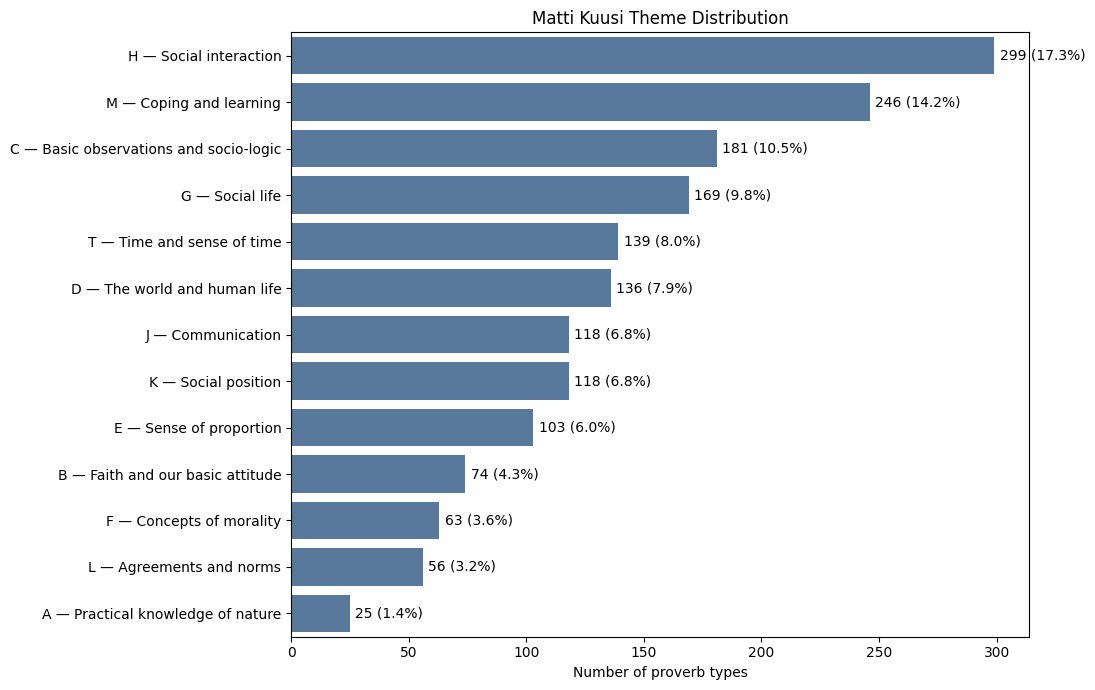

In [7]:
plt.figure(figsize=(11, 7))

ax = sns.barplot(
    data=theme_distribution,
    x="records",
    y="theme",
    color="#4C78A8"
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"{records:,} ({percentage:.1f}%)"
        for records, percentage in zip(
            theme_distribution["records"],
            theme_distribution["percentage"]
        )
    ],
    padding=4
)

plt.title("Matti Kuusi Theme Distribution")
plt.xlabel("Number of proverb types")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mk_theme_distribution_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

### 4.3 Proverb and variant coverage

Every record contains one primary text for analysis. Alternative formulations are retained in separate variant fields, allowing future retrieval methods to use more of the available textual evidence without treating every formulation as an independent proverb type.

In [8]:
text_fields = {
    "Primary text": "proverb_primary_en",
    "Second formulation": "proverb_variant_2",
    "Third formulation": "proverb_variant_3",
    "Fourth formulation": "proverb_variant_4",
    "Additional formulations": "proverb_variant_extra",
}

coverage_rows = []

for label, column in text_fields.items():
    present = (
        kuusi[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .ne("")
    )

    coverage_rows.append({
        "text field": label,
        "records": int(present.sum()),
        "percentage": round(present.mean() * 100, 1),
    })

variant_coverage = pd.DataFrame(coverage_rows)

english_primary = (
    pd.to_numeric(
        kuusi["proverb_primary_en_is_english"],
        errors="coerce",
    )
    .fillna(0)
    .eq(1)
)

display(variant_coverage)

print(
    "Primary texts flagged as English:",
    f"{english_primary.sum():,} of {len(kuusi):,}",
)

,text field,records,percentage
0,Primary text,1727,100.0
1,Second formulation,1401,81.1
2,Third formulation,1158,67.1
3,Fourth formulation,583,33.8
4,Additional formulations,155,9.0


Primary texts flagged as English: 1,693 of 1,727


### 4.4 Language metadata

Language information was extracted only when an identifiable language or translation tag appeared in the source text. The resulting fields describe available metadata, not the complete linguistic distribution of the proverb types.

In [9]:
has_language_tag = (
    pd.to_numeric(
        kuusi["has_language_or_translation_tag"],
        errors="coerce",
    )
    .fillna(0)
    .eq(1)
)

language_values = (
    kuusi.loc[
        has_language_tag,
        "language_names_extracted",
    ]
    .dropna()
    .str.split("|")
    .explode()
    .str.strip()
)

language_values = language_values[
    language_values.ne("")
]

language_counts = (
    language_values
    .value_counts()
    .rename_axis("language")
    .reset_index(name="records")
)

language_summary = pd.DataFrame({
    "measure": [
        "Records with language or translation metadata",
        "Records without this metadata",
        "Unique extracted language labels",
    ],
    "count": [
        int(has_language_tag.sum()),
        int((~has_language_tag).sum()),
        language_values.nunique(),
    ],
})

display(language_summary)
display(language_counts.head(10))

,measure,count
0,Records with language or translation metadata,730
1,Records without this metadata,997
2,Unique extracted language labels,54


,language,records
0,Latin,626
1,Polish,16
2,Chinese,14
3,Finnish,8
4,Ovambo/Afr.,6
5,Maltese,6
6,Japanese,5
7,Persian,3
8,Egyptian,3
9,Swedish,2


Language or translation metadata is available for 730 records. Latin is by far the most frequently extracted label, while most other languages appear much less often. This imbalance reflects how the source records were documented and should not be interpreted as representative language coverage.

### 4.5 Distribution patterns

The Matti Kuusi typology assigns proverb types to 12 broad distribution categories. These categories represent documented cultural areas rather than precise countries, origins, or observed usage frequencies.

| Code | Distribution category |
|---|---|
| G | Global type |
| F | Finnish and Baltic Sea cultures |
| E | Europe in general |
| En | Northern Europe |
| Ew | Western Europe and the Americas |
| Es | Southern Europe |
| Ee | Eastern Europe |
| Eb | The Balkans |
| A | Sub-Saharan Africa |
| I | Islamic cultures |
| O | Older Asiatic cultures |
| P | Pacific area |

Several categories may apply to the same proverb type. Consequently, the percentages below measure documented coverage and do not sum to 100%. Some categories also overlap geographically: for example, the general European category overlaps with the more specific European subregions.

The analysis examines:

1. overall coverage by distribution category;
2. variation in distribution coverage across themes; and
3. the most common combinations of distribution codes.

The category definitions follow Lauhakangas (2001, Appendix 3, pp. 125–126).

In [10]:
distribution_labels = {
    "distribution_G_global_type": "Global type",
    "distribution_F_finnish_baltic_sea": "Finnish and Baltic Sea cultures",
    "distribution_E_europe_general": "Europe (general)",
    "distribution_En_northern_europe": "Northern Europe",
    "distribution_Ew_western_europe_americas": (
        "Western Europe and the Americas"
    ),
    "distribution_Es_southern_europe": "Southern Europe",
    "distribution_Ee_eastern_europe": "Eastern Europe",
    "distribution_Eb_balkans": "The Balkans",
    "distribution_A_sub_saharan_africa": "Sub-Saharan Africa",
    "distribution_I_islamic_cultures": "Islamic cultures",
    "distribution_O_older_asiatic_cultures": "Older Asiatic cultures",
    "distribution_P_pacific_area": "Pacific area",
}

# calculate the number and percentage of records in each category
distribution_summary = pd.DataFrame({
    "distribution_category": distribution_labels.values(),
    "records": [
        pd.to_numeric(kuusi[column], errors="coerce")
        .fillna(0)
        .sum()
        for column in distribution_labels
    ],
})

distribution_summary["records"] = (
    distribution_summary["records"].astype(int)
)

distribution_summary["percentage"] = (
    distribution_summary["records"] / len(kuusi) * 100
).round(1)

distribution_summary = distribution_summary.sort_values(
    "records",
    ascending=True,
)

display(
    distribution_summary.sort_values(
        "records",
        ascending=False,
    )
)

,distribution_category,records,percentage
2,Europe (general),1121,64.9
1,Finnish and Baltic Sea cultures,813,47.1
10,Older Asiatic cultures,639,37.0
9,Islamic cultures,481,27.9
8,Sub-Saharan Africa,295,17.1
0,Global type,275,15.9
4,Western Europe and the Americas,263,15.2
5,Southern Europe,88,5.1
11,Pacific area,79,4.6
6,Eastern Europe,77,4.5


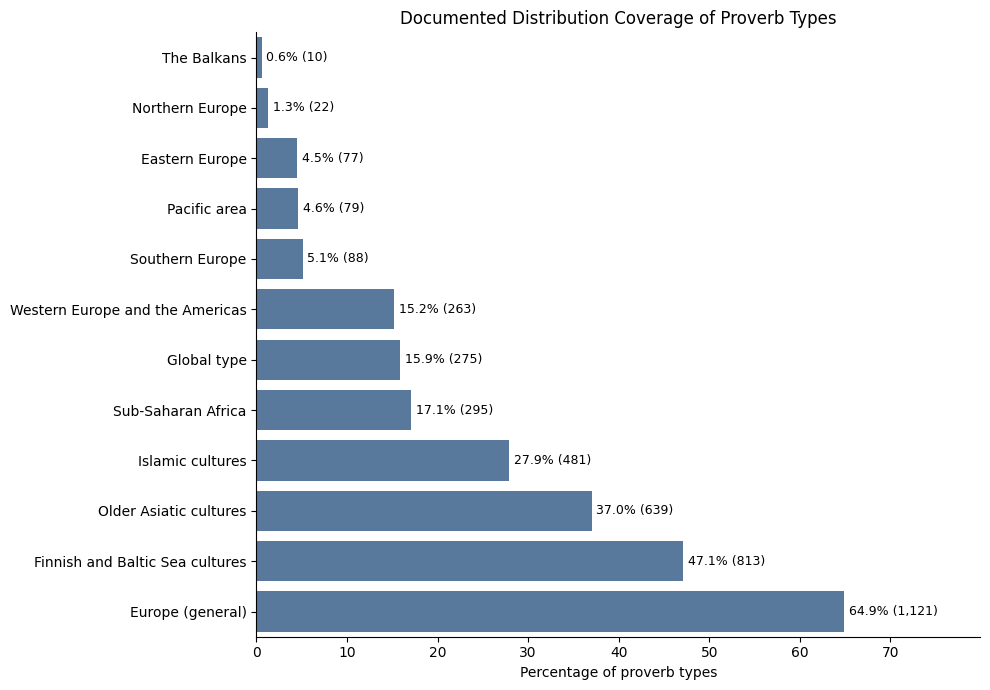

In [11]:
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=distribution_summary,
    x="percentage",
    y="distribution_category",
    color="#4c78a8",
)

# percentage + record count beside each bar
for container, records in zip(
    ax.containers[0],
    distribution_summary["records"],
):
    ax.text(
        container.get_width() + 0.5,
        container.get_y() + container.get_height() / 2,
        f"{container.get_width():.1f}% ({records:,})",
        va="center",
        fontsize=9,
    )

plt.title("Documented Distribution Coverage of Proverb Types")
plt.xlabel("Percentage of proverb types")
plt.ylabel("")
plt.xlim(0, distribution_summary["percentage"].max() + 15)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mk_region_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

The chart measures the proportion of proverb types associated with each distribution category. Because the classification is multilabel, a record may contribute to several bars. The results describe the composition of the Kuusi database rather than the real-world prevalence of proverbs within these cultural areas.

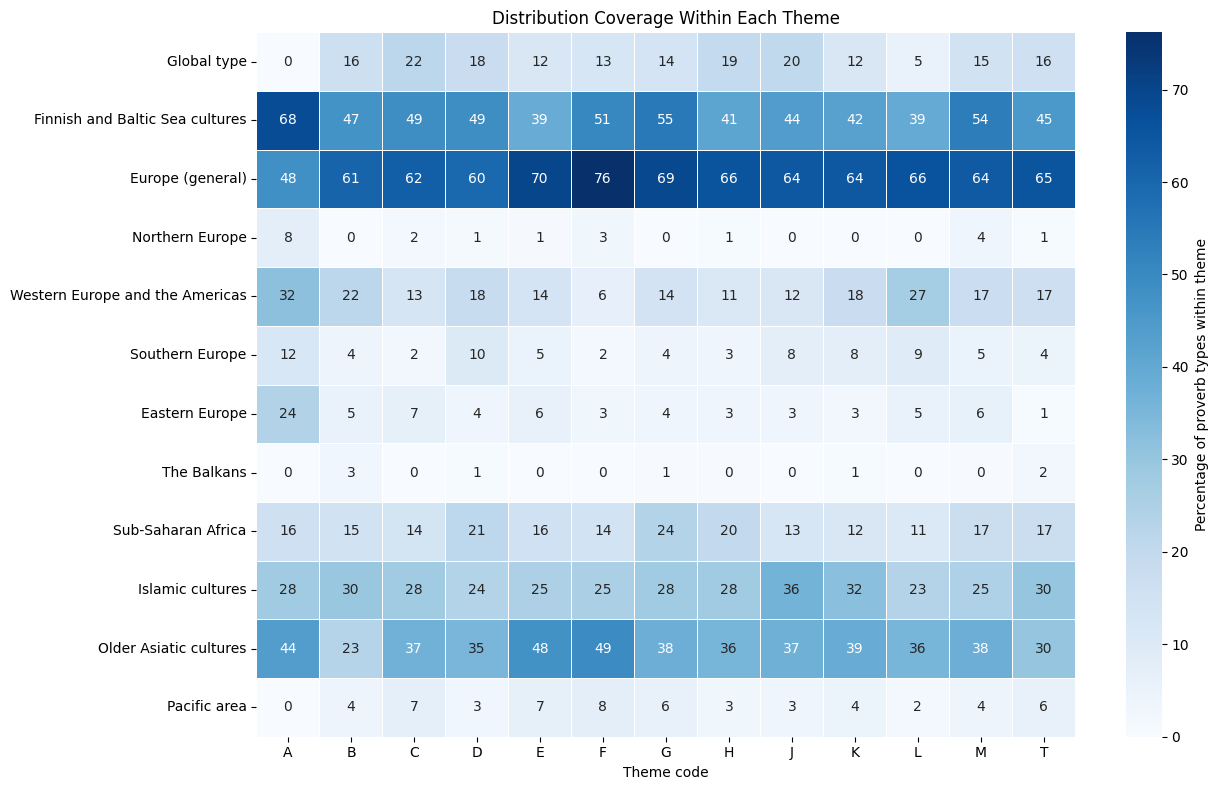

In [12]:
# calculate the percentage of records in each theme assigned to each category
theme_distribution_heatmap = (
    kuusi
    .groupby("theme")[list(distribution_labels)]
    .mean()
    .mul(100)
    .rename(columns=distribution_labels)
    .transpose()
)

plt.figure(figsize=(13, 8))

sns.heatmap(
    theme_distribution_heatmap,
    cmap="Blues",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={
        "label": "Percentage of proverb types within theme"
    },
)

plt.title("Distribution Coverage Within Each Theme")
plt.xlabel("Theme code")
plt.ylabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mk_theme_distribution_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

The heatmap shows the percentage of proverb types within each theme associated with each distribution category. Darker cells indicate greater documented coverage within that theme.

Using within-theme percentages rather than raw counts makes themes of different sizes more comparable. However, the patterns may still reflect differences in documentation and classification rather than genuine cultural differences in proverbial content.

In [13]:
distribution_codes = {
    "G": "distribution_G_global_type",
    "F": "distribution_F_finnish_baltic_sea",
    "E": "distribution_E_europe_general",
    "En": "distribution_En_northern_europe",
    "Ew": "distribution_Ew_western_europe_americas",
    "Es": "distribution_Es_southern_europe",
    "Ee": "distribution_Ee_eastern_europe",
    "Eb": "distribution_Eb_balkans",
    "A": "distribution_A_sub_saharan_africa",
    "I": "distribution_I_islamic_cultures",
    "O": "distribution_O_older_asiatic_cultures",
    "P": "distribution_P_pacific_area",
}

# reconstruct a consistent label for each record's code combination
def make_distribution_combination(row):
    codes = [
        code
        for code, column in distribution_codes.items()
        if pd.to_numeric(row[column], errors="coerce") == 1
    ]
    return " + ".join(codes) if codes else "No distribution code"


distribution_combinations = kuusi.apply(
    make_distribution_combination,
    axis=1,
)

top_combinations = (
    distribution_combinations
    .value_counts()
    .head(12)
    .rename_axis("code_combination")
    .reset_index(name="records")
)

top_combinations["percentage"] = (
    top_combinations["records"] / len(kuusi) * 100
).round(1)

display(top_combinations)

,code_combination,records,percentage
0,G,274,15.9
1,E,209,12.1
2,F + E,152,8.8
3,F + E + I + O,141,8.2
4,F + E + O,109,6.3
5,F + E + I,77,4.5
6,E + O,70,4.1
7,F + E + A + O,66,3.8
8,E + I + O,55,3.2
9,E + I,49,2.8


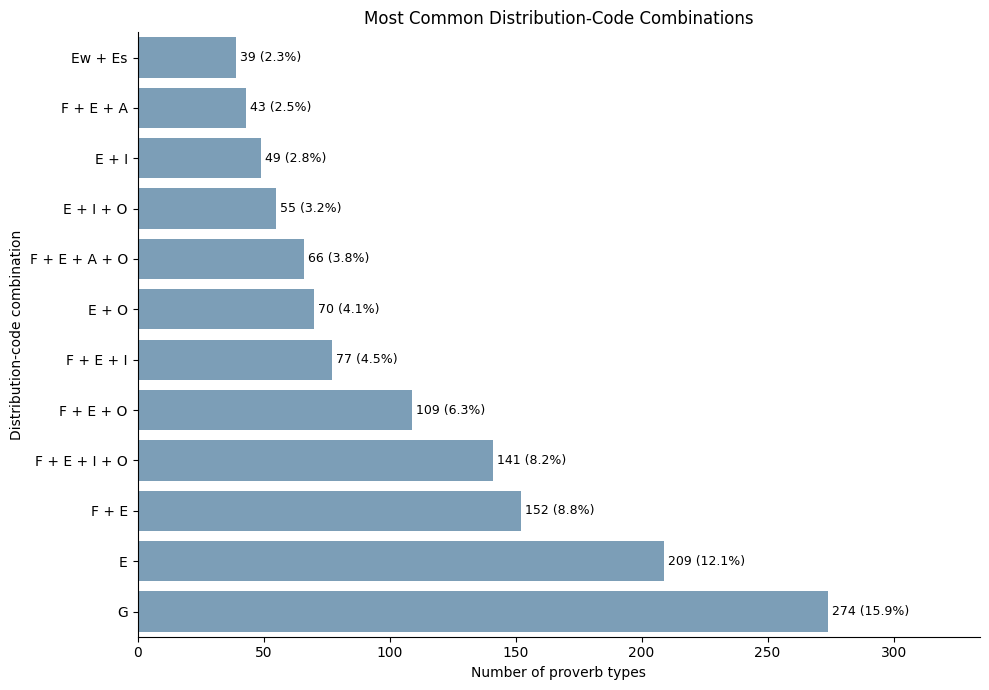

In [14]:
combination_plot = top_combinations.sort_values(
    "records",
    ascending=True,
)

plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=combination_plot,
    x="records",
    y="code_combination",
    color="#72a0c1",
)

ax.bar_label(
    ax.containers[0],
    labels=[
        f"{count:,} ({percentage:.1f}%)"
        for count, percentage in zip(
            combination_plot["records"],
            combination_plot["percentage"],
        )
    ],
    padding=3,
    fontsize=9,
)

plt.title("Most Common Distribution-Code Combinations")
plt.xlabel("Number of proverb types")
plt.ylabel("Distribution-code combination")
plt.xlim(0, combination_plot["records"].max() * 1.22)
sns.despine()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mk_theme_distribution_combos.png", dpi=300, bbox_inches="tight")
plt.show()

The combination chart preserves the multilabel structure that is hidden when each category is counted independently. It shows which broad cultural areas are most frequently documented together for the same proverb type.

### 4.6 Dataset limitations

Several limitations affect how the cleaned corpus should be interpreted:

- The records represent proverb types or families, not individual occurrences of proverb use.
- The dataset does not provide frequency information, conversational context, dates of use, or speaker characteristics.
- `proverb_primary_en` provides one consistent modeling field, but some records are flagged because their primary text is not fully English.
- Alternative formulations and language tags are unevenly available across records.
- Language labels describe metadata preserved in the source text rather than complete multilingual coverage.
- Distribution categories are broad historical groupings. They should not be interpreted as precise origins, country-level classifications, or evidence of equal prevalence across communities.
- Several categories can apply to the same proverb type.
- Proverb parsing relies partly on textual separators and metadata patterns. The original text and parsing-warning field are retained so uncertain cases remain auditable.
- The inherited hierarchy and cross-references reflect expert typological decisions, but they do not encode the precise semantic relationship between every linked proverb type.

The cleaned corpus is therefore most appropriate for exploratory classification, retrieval, and semantic comparison. It does not support direct claims about proverb frequency, cultural ownership, or meaning in a specific context.

## 5. Computational explorations

### 5.1 Lexical versus embedding-based proverb retrieval

The notebook compares three exploratory approaches: direct retrieval, Wisdom
Extractor lexical clustering, and unconstrained LLM category induction. The
retrieval experiment is presented first because it offers the clearest controlled
method comparison. It asks:

> Can sentence embeddings retrieve proverbs with related meanings even when
> they use different words?

Two retrieval methods are compared:

| Method | Representation | Main signal |
|---|---|---|
| Word TF-IDF | Individual words and two-word phrases | Shared vocabulary and phrasing |
| MiniLM sentence embeddings | Dense vectors representing complete phrases | Proximity in the model's embedding space |

The lexical baseline uses word-level TF-IDF with unigrams and bigrams. The
embedding-based method uses the pretrained `all-MiniLM-L6-v2` sentence-transformer,
which maps each proverb into a 384-dimensional vector. Cosine similarity is
used to retrieve the five nearest neighbours for five purposefully selected
anchor proverbs.

The anchors were chosen as interpretable qualitative cases rather than as a
representative random sample. The experiment is therefore an exploratory
retrieval comparison, not a general performance benchmark.

In [15]:
import sentence_transformers

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import (
    TfidfVectorizer,
)
from sklearn.metrics.pairwise import cosine_similarity

# Use the cleaned dataframe already created in Section 3.
required_retrieval_columns = {
    "kuusi_id",
    "proverb_primary_en",
    "theme",
    "proverb_primary_en_is_english",
}

missing_retrieval_columns = (
    required_retrieval_columns - set(kuusi.columns)
)

if missing_retrieval_columns:
    raise ValueError(
        "Missing required columns: "
        f"{sorted(missing_retrieval_columns)}"
    )

nonempty_primary_mask = (
    kuusi["proverb_primary_en"].notna()
    & kuusi["proverb_primary_en"].astype(str).str.strip().ne("")
)

english_ready_mask = (
    pd.to_numeric(
        kuusi["proverb_primary_en_is_english"],
        errors="coerce",
    )
    .fillna(0)
    .eq(1)
)

retrieval_candidates = kuusi.loc[
    nonempty_primary_mask & english_ready_mask,
    [
        "kuusi_id",
        "proverb_primary_en",
        "theme",
    ],
].copy()

duplicate_id_rows = int(
    retrieval_candidates["kuusi_id"].duplicated().sum()
)

retrieval_df = (
    retrieval_candidates
    .drop_duplicates(subset="kuusi_id")
    .reset_index(drop=True)
)

retrieval_filter_summary = pd.DataFrame({
    "stage": [
        "Cleaned corpus",
        "Non-empty primary English text",
        "Marked English-ready",
        "Duplicate kuusi_id rows removed",
        "Final retrieval corpus",
    ],
    "records": [
        len(kuusi),
        int(nonempty_primary_mask.sum()),
        int((nonempty_primary_mask & english_ready_mask).sum()),
        duplicate_id_rows,
        len(retrieval_df),
    ],
})

if len(retrieval_df) != 1_693:
    raise ValueError(
        "Expected 1,693 English-ready records in the retrieval corpus, "
        f"found {len(retrieval_df):,}."
    )

retrieval_texts = (
    retrieval_df["proverb_primary_en"]
    .astype(str)
    .tolist()
)

print("Retrieval corpus:", retrieval_df.shape)
print("scikit-learn version:", sklearn.__version__)
print(
    "sentence-transformers version:",
    sentence_transformers.__version__,
)

display(retrieval_filter_summary)
display(retrieval_df.head())

Retrieval corpus: (1693, 3)
scikit-learn version: 1.9.0
sentence-transformers version: 5.6.1


,stage,records
0,Cleaned corpus,1727
1,Non-empty primary English text,1727
2,Marked English-ready,1693
3,Duplicate kuusi_id rows removed,0
4,Final retrieval corpus,1693


,kuusi_id,proverb_primary_en,theme
0,A1a-13,Water will stand in a hollow,A
1,A1a-14,Let things take their course,A
2,A1a-17,Fire is a good servant but a bad master,A
3,A1b-17,"Praise the sea, but keep on land",A
4,A1b-19,"Let him that knows not how to pray, go to sea",A


#### 5.1.1 Anchor proverbs

Five anchor proverbs were purposefully selected to cover different kinds of
wording and meaning. Some state their lesson relatively directly, while others
communicate it through metaphor, contrast, or conventional phrasing.

This purposeful selection makes the results easier to interpret, but the five
anchors are not representative of the full corpus and cannot establish general
retrieval performance. When an anchor title occurs under multiple Kuusi codes,
the alphabetically first `kuusi_id` is used as the query record; records with
the same normalized title are excluded from its retrieved neighbours.

In [16]:
ANCHOR_SEARCH_TERMS = [
    "Fire is a good servant but a bad master",
    "Seeing is believing",
    "Time and tide wait for no man",
    "Let things take their course",
    "Praise the sea, but keep on land",
]


def normalize_for_lookup(text):
    """Normalize punctuation and capitalization for anchor lookup."""
    return re.sub(
        r"[^a-z0-9]+",
        " ",
        str(text).casefold(),
    ).strip()


normalized_corpus_text = (
    retrieval_df["proverb_primary_en"]
    .map(normalize_for_lookup)
)

anchor_rows = []

for search_term in ANCHOR_SEARCH_TERMS:
    normalized_term = normalize_for_lookup(search_term)

    matches = retrieval_df.loc[
        normalized_corpus_text.eq(normalized_term)
    ].copy()

    if matches.empty:
        raise ValueError(f"Anchor not found: {search_term!r}")

    selected = matches.sort_values("kuusi_id").iloc[0]

    anchor_rows.append({
        "corpus_index": int(selected.name),
        "kuusi_id": selected["kuusi_id"],
        "proverb_primary_en": selected["proverb_primary_en"],
        "theme": selected["theme"],
        "search_term": search_term,
        "number_of_matches": len(matches),
    })

anchor_df = pd.DataFrame(anchor_rows)

if len(anchor_df) != len(ANCHOR_SEARCH_TERMS):
    raise AssertionError("Not all retrieval anchors were resolved.")

print(
    f"Anchor queries matched: {len(anchor_df)} of "
    f"{len(ANCHOR_SEARCH_TERMS)}"
)

display(
    anchor_df[
        [
            "kuusi_id",
            "proverb_primary_en",
            "theme",
            "number_of_matches",
        ]
    ]
)

Anchor queries matched: 5 of 5


,kuusi_id,proverb_primary_en,theme,number_of_matches
0,A1a-17,Fire is a good servant but a bad master,A,1
1,H1d-13,Seeing is believing,H,2
2,C3d-10,Time and tide wait for no man,C,2
3,A1a-14,Let things take their course,A,1
4,A1b-17,"Praise the sea, but keep on land",A,1


#### 5.1.2 Retrieval methods

The word-level TF-IDF baseline represents each proverb using individual words
and two-word phrases. It therefore prioritizes shared vocabulary and phrasing.

For embedding-based retrieval, each complete English proverb was encoded as a
384-dimensional dense vector using the pretrained
[`sentence-transformers/all-MiniLM-L6-v2`](https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2)
model. The model was selected because it is a compact sentence-transformer
designed for semantic similarity and information-retrieval tasks, making it
practical for an exploratory comparison across 1,693 short proverb texts.
The exact model identifier used here is `sentence-transformers/all-MiniLM-L6-v2`.
On its first run, Sentence Transformers downloads the model files from the
Hugging Face Hub, so internet access is required unless they are already cached.
The model was used without additional training or fine-tuning.

Cosine similarity was used to rank candidates under both methods. Identical
English titles were excluded because some titles occur under multiple Kuusi
classification codes. Similarity scores were used only to rank results within
each method and were not treated as directly comparable across TF-IDF and
MiniLM sentence embeddings. A high embedding similarity is not evidence that
two proverbs are semantically equivalent.

Although the embedding model can identify relationships beyond exact word
overlap, it was not trained specifically on proverbs. Its similarity scores may
therefore reflect shared topics, imagery, or sentence structure rather than the
same underlying lesson.

In [17]:
TFIDF_METHOD = "Word TF-IDF"
EMBEDDING_METHOD = "MiniLM sentence embeddings"
MODEL_ID = "sentence-transformers/all-MiniLM-L6-v2"
TOP_K = 5

# lexical representation using words and two-word phrases.
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=1,
    sublinear_tf=True,
)

tfidf_matrix = tfidf_vectorizer.fit_transform(
    retrieval_texts
)

# Dense embedding representation. The model downloads from Hugging Face on
# first use unless it is already present in the local model cache.
embedding_model = SentenceTransformer(MODEL_ID)
embedding_dimension = embedding_model.get_embedding_dimension()

if embedding_dimension != 384:
    raise ValueError(
        f"Expected 384-dimensional embeddings, found {embedding_dimension}."
    )

embedding_matrix = embedding_model.encode(
    retrieval_texts,
    batch_size=64,
    show_progress_bar=True,
    convert_to_numpy=True,
    normalize_embeddings=True,
)

if embedding_matrix.shape != (len(retrieval_df), embedding_dimension):
    raise ValueError("Embedding matrix dimensions do not match the corpus.")

print("TF-IDF matrix:", tfidf_matrix.shape)
print("Embedding model identifier:", MODEL_ID)
print("Embedding matrix:", embedding_matrix.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

TF-IDF matrix: (1693, 10154)
Embedding model identifier: sentence-transformers/all-MiniLM-L6-v2
Embedding matrix: (1693, 384)


In [18]:
def retrieve_neighbours(
    representation,
    method_name,
    anchor_table,
    corpus,
    top_k=5,
):
    """Retrieve unique neighbours by lexical or embedding similarity."""
    result_rows = []

    normalized_titles = (
        corpus["proverb_primary_en"]
        .map(normalize_for_lookup)
    )

    for anchor in anchor_table.itertuples(index=False):
        anchor_index = anchor.corpus_index
        anchor_title = normalize_for_lookup(
            anchor.proverb_primary_en
        )

        if method_name == TFIDF_METHOD:
            similarities = cosine_similarity(
                representation[anchor_index],
                representation,
            ).ravel()
        else:
            similarities = (
                representation
                @ representation[anchor_index]
            ).copy()

        # Rank all corpus records from most to least similar.
        ranked_indices = np.argsort(
            -similarities,
            kind="stable",
        )

        selected_indices = []
        seen_candidate_titles = {anchor_title}

        for candidate_index in ranked_indices:
            candidate_title = normalized_titles.iloc[
                candidate_index
            ]

            # Skip the query title and duplicate candidate titles.
            if candidate_title in seen_candidate_titles:
                continue

            selected_indices.append(candidate_index)
            seen_candidate_titles.add(candidate_title)

            if len(selected_indices) == top_k:
                break

        if len(selected_indices) != top_k:
            raise ValueError(
                f"Could not retrieve {top_k} unique titles for "
                f"{anchor.kuusi_id}."
            )

        for rank, candidate_index in enumerate(
            selected_indices,
            start=1,
        ):
            candidate = corpus.iloc[candidate_index]

            result_rows.append({
                "method": method_name,
                "query_id": anchor.kuusi_id,
                "query_text": anchor.proverb_primary_en,
                "query_theme": anchor.theme,
                "rank": rank,
                "candidate_id": candidate["kuusi_id"],
                "candidate_text": candidate[
                    "proverb_primary_en"
                ],
                "candidate_theme": candidate["theme"],
                "similarity": round(
                    float(similarities[candidate_index]),
                    4,
                ),
            })

    return pd.DataFrame(result_rows)


tfidf_results = retrieve_neighbours(
    representation=tfidf_matrix,
    method_name=TFIDF_METHOD,
    anchor_table=anchor_df,
    corpus=retrieval_df,
    top_k=TOP_K,
)

embedding_results = retrieve_neighbours(
    representation=embedding_matrix,
    method_name=EMBEDDING_METHOD,
    anchor_table=anchor_df,
    corpus=retrieval_df,
    top_k=TOP_K,
)

retrieval_results = pd.concat(
    [tfidf_results, embedding_results],
    ignore_index=True,
)

method_counts = retrieval_results["method"].value_counts().to_dict()
expected_per_method = len(anchor_df) * TOP_K

if method_counts != {
    TFIDF_METHOD: expected_per_method,
    EMBEDDING_METHOD: expected_per_method,
}:
    raise ValueError(f"Unexpected retrieval result counts: {method_counts}")

print("Total retrieved results:", len(retrieval_results))
print(
    "Results per method:",
    method_counts,
)

display(retrieval_results.head(10))

Total retrieved results: 50
Results per method: {'Word TF-IDF': 25, 'MiniLM sentence embeddings': 25}


,method,query_id,query_text,query_theme,rank,candidate_id,candidate_text,candidate_theme,similarity
0,Word TF-IDF,A1a-17,Fire is a good servant but a bad master,A,1,K2k-21,Money is a good servant but a bad master,K,0.8441
1,Word TF-IDF,A1a-17,Fire is a good servant but a bad master,A,2,H7k-28,Fire is not quenched by fire,H,0.2206
2,Word TF-IDF,A1a-17,Fire is a good servant but a bad master,A,3,H3b-27b,Good company is a good coach,H,0.1675
3,Word TF-IDF,A1a-17,Fire is a good servant but a bad master,A,4,T1d-12,A little fire is quickly trodden out,T,0.1673
4,Word TF-IDF,A1a-17,Fire is a good servant but a bad master,A,5,M9a-12,Advercity is a good teacher,M,0.1577
5,Word TF-IDF,H1d-13,Seeing is believing,H,1,C3g-10,Seeing is believing; feeling is the naked truth,C,0.5894
6,Word TF-IDF,H1d-13,Seeing is believing,H,2,D3j-10,He is rich who is satisfied,D,0.0336
7,Word TF-IDF,H1d-13,Seeing is believing,H,3,J1c-10,All that is known is not told,J,0.0334
8,Word TF-IDF,H1d-13,Seeing is believing,H,4,G6a-12,All is gay that is green,G,0.0330
9,Word TF-IDF,H1d-13,Seeing is believing,H,5,M9a-31,"Art is long, life is short",M,0.0323


In [19]:
for anchor in anchor_df.itertuples(index=False):
    print(
        "\nANCHOR:",
        anchor.proverb_primary_en,
        f"({anchor.kuusi_id})",
    )

    comparison = (
        retrieval_results.loc[
            retrieval_results["query_id"].eq(anchor.kuusi_id),
            [
                "method",
                "rank",
                "candidate_text",
                "similarity",
                "candidate_theme",
            ],
        ]
        .sort_values(["method", "rank"])
        .reset_index(drop=True)
    )

    display(comparison)


ANCHOR: Fire is a good servant but a bad master (A1a-17)


,method,rank,candidate_text,similarity,candidate_theme
0,MiniLM sentence embeddings,1,Money is a good servant but a bad master,0.6919,K
1,MiniLM sentence embeddings,2,He who serves God has a good master,0.5913,B
2,MiniLM sentence embeddings,3,Don't play with fire,0.5563,M
3,MiniLM sentence embeddings,4,"Fire is the test of gold, adversity of friendship",0.5562,C
4,MiniLM sentence embeddings,5,"So many servants, so many enemies",0.5405,K
5,Word TF-IDF,1,Money is a good servant but a bad master,0.8441,K
6,Word TF-IDF,2,Fire is not quenched by fire,0.2206,H
7,Word TF-IDF,3,Good company is a good coach,0.1675,H
8,Word TF-IDF,4,A little fire is quickly trodden out,0.1673,T
9,Word TF-IDF,5,Advercity is a good teacher,0.1577,M



ANCHOR: Seeing is believing (H1d-13)


,method,rank,candidate_text,similarity,candidate_theme
0,MiniLM sentence embeddings,1,Seeing is believing; feeling is the naked truth,0.7759,C
1,MiniLM sentence embeddings,2,"God sees all things, himself unseen",0.5178,B
2,MiniLM sentence embeddings,3,The eye that sees all things sees not itself,0.5167,H
3,MiniLM sentence embeddings,4,Love is blind,0.4490,D
4,MiniLM sentence embeddings,5,Believe only half of what you hear,0.4404,J
5,Word TF-IDF,1,Seeing is believing; feeling is the naked truth,0.5894,C
6,Word TF-IDF,2,He is rich who is satisfied,0.0336,D
7,Word TF-IDF,3,All that is known is not told,0.0334,J
8,Word TF-IDF,4,All is gay that is green,0.0330,G
9,Word TF-IDF,5,"Art is long, life is short",0.0323,M



ANCHOR: Time and tide wait for no man (C3d-10)


,method,rank,candidate_text,similarity,candidate_theme
0,MiniLM sentence embeddings,1,Every tide has its ebb,0.5541,T
1,MiniLM sentence embeddings,2,We lose nothing by waiting,0.4769,T
2,MiniLM sentence embeddings,3,Whatever man has done man can do,0.4108,H
3,MiniLM sentence embeddings,4,No man is an island,0.3962,G
4,MiniLM sentence embeddings,5,Everything has its time,0.3928,T
5,Word TF-IDF,1,No man is indispensable,0.1996,H
6,Word TF-IDF,2,No man is an island,0.1781,G
7,Word TF-IDF,3,No man is content with his lot,0.1416,D
8,Word TF-IDF,4,No man can serve two masters,0.1389,M
9,Word TF-IDF,5,With time and art the mulberry leafs grow to b...,0.1316,T



ANCHOR: Let things take their course (A1a-14)


,method,rank,candidate_text,similarity,candidate_theme
0,MiniLM sentence embeddings,1,"Do what you ought, let come what may",0.5228,F
1,MiniLM sentence embeddings,2,We learn by teaching,0.4902,M
2,MiniLM sentence embeddings,3,Keep your fellows' counsel and your own,0.4012,M
3,MiniLM sentence embeddings,4,Moderation in all things,0.3956,D
4,MiniLM sentence embeddings,5,"Not to give chase to those who leave, nor refu...",0.3887,H
5,Word TF-IDF,1,A middle course is safest,0.1288,M
6,Word TF-IDF,2,Wolves lose their teeth but not their memory,0.1215,C
7,Word TF-IDF,3,Cats hide their claws,0.1031,H
8,Word TF-IDF,4,First things first,0.0997,M
9,Word TF-IDF,5,Time cures all things,0.0928,T



ANCHOR: Praise the sea, but keep on land (A1b-17)


,method,rank,candidate_text,similarity,candidate_theme
0,MiniLM sentence embeddings,1,To do good to an ungrateful man is to throw ro...,0.5572,H
1,MiniLM sentence embeddings,2,A great ship asks deep waters.,0.5216,C
2,MiniLM sentence embeddings,3,Praise day at night and life at the end,0.5107,T
3,MiniLM sentence embeddings,4,Self-praise stinks,0.5015,F
4,MiniLM sentence embeddings,5,There is the sea - and who shall drain it dry?...,0.4888,C
5,Word TF-IDF,1,"Pray to God, but keep the hammer going",0.1841,B
6,Word TF-IDF,2,Self-praise is no praise,0.1611,F
7,Word TF-IDF,3,He pours water into the sea,0.1583,M
8,Word TF-IDF,4,All rivers run into the sea,0.1554,B
9,Word TF-IDF,5,Wine has drowned more than the sea,0.1524,D


In [20]:
pd.set_option("display.max_colwidth", None)

display(
    retrieval_results.loc[
        retrieval_results["query_id"].eq("A1b-17"),
        ["method", "rank", "candidate_text", "similarity"],
    ].sort_values(["method", "rank"])
)

,method,rank,candidate_text,similarity
45,MiniLM sentence embeddings,1,To do good to an ungrateful man is to throw rose-water in the sea,0.5572
46,MiniLM sentence embeddings,2,A great ship asks deep waters.,0.5216
47,MiniLM sentence embeddings,3,Praise day at night and life at the end,0.5107
48,MiniLM sentence embeddings,4,Self-praise stinks,0.5015
49,MiniLM sentence embeddings,5,There is the sea - and who shall drain it dry? (Aischylos),0.4888
20,Word TF-IDF,1,"Pray to God, but keep the hammer going",0.1841
21,Word TF-IDF,2,Self-praise is no praise,0.1611
22,Word TF-IDF,3,He pours water into the sea,0.1583
23,Word TF-IDF,4,All rivers run into the sea,0.1554
24,Word TF-IDF,5,Wine has drowned more than the sea,0.1524


#### 5.1.3 Example interpretation: “Praise the sea, but keep on land”

The anchor advises admiring something potentially dangerous while maintaining a prudent distance. Under the strict manual-evaluation criterion, **none of the five results from either method expressed the same or a closely related lesson**.

TF-IDF primarily retrieved shared words or sentence structures. For example, “Pray to God, but keep the hammer going” follows a similar “do one thing, but also do another” construction, while several other results merely contain *praise* or *sea*. The MiniLM sentence embeddings produced broader associations involving the sea, praise, and evaluative statements, but still failed to recover the anchor’s specific lesson about caution.

This example shows that sentence embeddings can move beyond exact word overlap without necessarily capturing the underlying proverbial meaning. A relatively high similarity score therefore indicates representational closeness, not semantic equivalence. Because this is only one purposefully selected anchor, it should be treated as an illustrative failure case rather than evidence of overall method performance.


### 5.2 Wisdom Extractor lexical-clustering baseline

#### 5.2.1 Method and purpose

Wisdom Extractor v19.22, developed by Vlad Belciug and Elena Pelican, was adapted to evaluate the cleaned Matti Kuusi corpus as an unconstrained lexical-clustering baseline. This notebook analyzes and validates the precomputed external-tool outputs; rebuilding the complete third-party tool is outside the public v0.1 workflow. The purpose was to test whether its deterministic pipeline could group proverb types with similar meanings and identify claims documented across several broad distribution areas.

Each unique Kuusi proverb type was treated as one clustering input. Its broad distribution areas were retained as separate attestations for calculating geographic coverage.

The implementation applies rule-based canonicalization and lexical normalization before representing the resulting claims with character-boundary 3–5-gram TF-IDF vectors. Cosine distances are then clustered using average-linkage agglomerative clustering. Because this run contained 1,689 proverb types, below the repository's 4,000-record agglomerative limit, it used average linkage rather than the large-corpus graph approximation.

The run used a lexical-distance threshold of $\tau = 0.35$ and supplied no human must-link or cannot-link constraints. This differs from the published Wisdom Extractor study, which selected $\tau = 0.25$ through sensitivity analysis. The present configuration should therefore be understood as the Kuusi-specific baseline evaluated in this project rather than an exact reproduction of the paper's selected configuration.

The main output units are:

- **proverb type:** one unique Kuusi record used as a clustering input;
- **cluster:** one or more proverb types grouped by the extractor;
- **support:** the number of unique proverb types in a cluster;
- **attestation support:** the number of type-to-distribution-area links in a cluster;
- **coverage:** the number of distinct broad distribution areas represented; and
- **representative claim:** one canonical wording used to identify the cluster.

Clusters are ranked using:

$$
\mathrm{wisdom\ score}
=
\mathrm{coverage}
+
0.3 \times \mathrm{support}
$$

This score measures recurrence in the source data. It does not directly measure semantic coherence, truth, usefulness, or wisdom quality.

The representative claims are normalized proverb wordings rather than complete interpretations of their meanings. Similarly, the output themes are deterministic first-match keyword labels used for navigation rather than learned or validated semantic categories.

This caution is consistent with the underlying typology. Lauhakangas (2001, pp. 62–64) explains that a proverb type may range from a concrete proverb title to a cluster of differently worded proverbs sharing an idea. The boundaries between proverb types, subgroups, and variants are therefore practical rather than objectively fixed.

#### 5.2.2 Output and cluster statistics

The following analysis summarizes the retained proverb types, exclusions, cluster sizes, and distribution-area coverage. The public workflow validates the publishable cluster, membership, exclusion, and sensitivity tables. The original run bundle did not include `run_metadata.json`, `RUN_NOTES.md`, or a verifiable recorded source hash, so source-hash agreement with the external run cannot be independently established; current input and output hashes are reported instead.

In [21]:
WISDOM_DIR = DATA_DIR / "wisdom_extractor"
WISDOM_PUBLIC_PATHS = {
    "clusters": WISDOM_DIR / "clusters.csv",
    "members": WISDOM_DIR / "cluster_members.csv",
    "exclusions": WISDOM_DIR / "exclusions.csv",
    "sensitivity": WISDOM_DIR / "sensitivity.csv",
}

missing_wisdom_files = [
    str(path)
    for path in WISDOM_PUBLIC_PATHS.values()
    if not path.is_file()
]
if missing_wisdom_files:
    raise FileNotFoundError(
        "Missing required Wisdom Extractor output(s): "
        + ", ".join(missing_wisdom_files)
    )

wisdom_clusters = pd.read_csv(WISDOM_PUBLIC_PATHS["clusters"])
wisdom_members = pd.read_csv(
    WISDOM_PUBLIC_PATHS["members"],
    low_memory=False,
)
wisdom_exclusions = pd.read_csv(WISDOM_PUBLIC_PATHS["exclusions"])
wisdom_sensitivity = pd.read_csv(WISDOM_PUBLIC_PATHS["sensitivity"])

required_wisdom_columns = {
    "clusters": {
        "cluster_id", "claim", "coverage", "support",
        "wisdom_score", "attestation_support", "theme",
    },
    "members": {
        "external_id", "text", "cluster_id",
        "distribution_areas", "attestation_count",
    },
    "exclusions": {
        "kuusi_id", "wisdom_extractor_exclusion_reason",
    },
    "sensitivity": {
        "tau", "clusters", "singletons",
        "singleton_pct", "method",
    },
}
for name, frame in {
    "clusters": wisdom_clusters,
    "members": wisdom_members,
    "exclusions": wisdom_exclusions,
    "sensitivity": wisdom_sensitivity,
}.items():
    missing_columns = required_wisdom_columns[name] - set(frame.columns)
    if missing_columns:
        raise ValueError(
            f"{name} is missing columns: {sorted(missing_columns)}"
        )

wisdom_source_audit = pd.DataFrame([
    {
        "file": path.relative_to(PROJECT_ROOT).as_posix(),
        "rows": len(frame),
        "sha256": file_sha256(path),
    }
    for path, frame in [
        (CLEAN_DATA_PATH, kuusi),
        (WISDOM_PUBLIC_PATHS["clusters"], wisdom_clusters),
        (WISDOM_PUBLIC_PATHS["members"], wisdom_members),
        (WISDOM_PUBLIC_PATHS["exclusions"], wisdom_exclusions),
        (WISDOM_PUBLIC_PATHS["sensitivity"], wisdom_sensitivity),
    ]
])

wisdom_provenance_status = pd.Series({
    "run_metadata.json available": (WISDOM_DIR / "run_metadata.json").is_file(),
    "RUN_NOTES.md available": (WISDOM_DIR / "RUN_NOTES.md").is_file(),
    "run source hash independently verified": False,
}, name="value")

display(wisdom_source_audit)
display(wisdom_provenance_status.to_frame())

,file,rows,sha256
0,data/processed/kuusi_proverb_types_clean.csv,1727,55f8a52fb011179fce1efeaf12c7b458072727f215830acb591e917fdd07fab8
1,data/wisdom_extractor/clusters.csv,1606,425abb85f8559343d9ec63d5960dfdef1023ba5c3cf97ee01d7a29528d22094f
2,data/wisdom_extractor/cluster_members.csv,1689,c6cd1da1f7a1828099a0cf46cdb677549a722c5e02698f3ce0e867ca57ba65a8
3,data/wisdom_extractor/exclusions.csv,38,cd6bd8302ac70813f9f6b08370a9efcdfa9ccaec9cdca3d0f39ef9acba7d9ce4
4,data/wisdom_extractor/sensitivity.csv,6,03d35217b4bac88141a2ecf55eff9de382c2cc6b2d5e7428ff9b45444638530d


,value
run_metadata.json available,False
RUN_NOTES.md available,False
run source hash independently verified,False


In [22]:
EXPECTED_WISDOM_MEMBERS = 1_689
EXPECTED_WISDOM_EXCLUSIONS = 38
EXPECTED_WISDOM_CLUSTERS = 1_606
EXPECTED_WISDOM_ATTESTATIONS = 4_068

member_ids = wisdom_members["external_id"].astype("string").str.strip()
excluded_ids = wisdom_exclusions["kuusi_id"].astype("string").str.strip()
clean_ids = kuusi["kuusi_id"].astype("string").str.strip()

assert len(wisdom_members) == EXPECTED_WISDOM_MEMBERS
assert len(wisdom_exclusions) == EXPECTED_WISDOM_EXCLUSIONS
assert len(wisdom_clusters) == EXPECTED_WISDOM_CLUSTERS
assert member_ids.notna().all() and not member_ids.duplicated().any()
assert excluded_ids.notna().all() and not excluded_ids.duplicated().any()
assert wisdom_clusters["cluster_id"].notna().all()
assert not wisdom_clusters["cluster_id"].duplicated().any()
assert set(member_ids).isdisjoint(set(excluded_ids))
assert set(member_ids) | set(excluded_ids) == set(clean_ids)
assert set(wisdom_members["cluster_id"]) == set(wisdom_clusters["cluster_id"])

member_area_rows = (
    wisdom_members[["external_id", "cluster_id", "distribution_areas"]]
    .assign(
        distribution_area=lambda frame: (
            frame["distribution_areas"].str.split("|", regex=False)
        )
    )
    .explode("distribution_area")
)
member_area_rows["distribution_area"] = (
    member_area_rows["distribution_area"].astype("string").str.strip()
)
assert member_area_rows["distribution_area"].notna().all()
assert member_area_rows["distribution_area"].ne("").all()
assert len(member_area_rows) == EXPECTED_WISDOM_ATTESTATIONS

attestations_by_member = member_area_rows.groupby("external_id").size()
recorded_attestations_by_member = (
    wisdom_members.set_index("external_id")["attestation_count"].sort_index()
)
assert attestations_by_member.equals(recorded_attestations_by_member)

cluster_indexed = wisdom_clusters.set_index("cluster_id").sort_index()
support_by_cluster = wisdom_members.groupby("cluster_id").size().sort_index()
attestations_by_cluster = member_area_rows.groupby("cluster_id").size().sort_index()
coverage_by_cluster = (
    member_area_rows.groupby("cluster_id")["distribution_area"]
    .nunique()
    .sort_index()
)
assert support_by_cluster.equals(cluster_indexed["support"])
assert attestations_by_cluster.equals(cluster_indexed["attestation_support"])
assert coverage_by_cluster.equals(cluster_indexed["coverage"])

expected_wisdom_score = (
    wisdom_clusters["coverage"] + 0.3 * wisdom_clusters["support"]
)
assert np.allclose(wisdom_clusters["wisdom_score"], expected_wisdom_score)

baseline_sensitivity = wisdom_sensitivity.loc[
    np.isclose(wisdom_sensitivity["tau"], 0.35)
]
assert len(baseline_sensitivity) == 1
assert int(baseline_sensitivity.iloc[0]["clusters"]) == EXPECTED_WISDOM_CLUSTERS
assert int(baseline_sensitivity.iloc[0]["singletons"]) == int(
    wisdom_clusters["support"].eq(1).sum()
)

multi_type_mask = wisdom_clusters["support"].gt(1)
cluster_summary = pd.Series({
    "Cleaned proverb types": len(kuusi),
    "Proverb types imported": len(wisdom_members),
    "Proverb types excluded": len(wisdom_exclusions),
    "Clusters produced": len(wisdom_clusters),
    "Type-to-area attestations": len(member_area_rows),
    "Singleton clusters": int(wisdom_clusters["support"].eq(1).sum()),
    "Multi-type clusters": int(multi_type_mask.sum()),
    "Types in multi-type clusters": int(
        wisdom_clusters.loc[multi_type_mask, "support"].sum()
    ),
})

wisdom_cross_file_checks = pd.Series({
    "Membership plus exclusions equals cleaned corpus": True,
    "Cluster support equals membership counts": True,
    "Attestation support equals type-area links": True,
    "Coverage equals unique areas per cluster": True,
    "Wisdom score = coverage + 0.3 × support": True,
    "Sensitivity row at tau=0.35 matches main clusters": True,
}, name="passed")

exclusion_summary = (
    wisdom_exclusions["wisdom_extractor_exclusion_reason"]
    .value_counts()
    .rename_axis("exclusion_reason")
    .reset_index(name="records")
)
assert exclusion_summary.set_index("exclusion_reason")["records"].to_dict() == {
    "not_english_ready": 34,
    "blank_distribution": 4,
}

display(cluster_summary.to_frame("value"))
display(exclusion_summary)
display(wisdom_cross_file_checks.to_frame())

,value
Cleaned proverb types,1727
Proverb types imported,1689
Proverb types excluded,38
Clusters produced,1606
Type-to-area attestations,4068
Singleton clusters,1527
Multi-type clusters,79
Types in multi-type clusters,162


,exclusion_reason,records
0,not_english_ready,34
1,blank_distribution,4


,passed
Membership plus exclusions equals cleaned corpus,True
Cluster support equals membership counts,True
Attestation support equals type-area links,True
Coverage equals unique areas per cluster,True
Wisdom score = coverage + 0.3 × support,True
Sensitivity row at tau=0.35 matches main clusters,True


In [23]:
# convert cluster counts into a table with counts and percentages
def summarize_distribution(column, label):
    summary = (
        wisdom_clusters[column]
        .value_counts()
        .sort_index()
        .rename_axis(label)
        .reset_index(name="clusters")
    )

    summary["percentage"] = (
        100
        * summary["clusters"]
        / len(wisdom_clusters)
    ).round(1)

    return summary


# summarize the number of proverb types in each cluster
support_distribution = summarize_distribution(
    "support",
    "proverb_types",
)

# summarize the number of distribution areas represented
coverage_distribution = summarize_distribution(
    "coverage",
    "distribution_areas",
)

display(support_distribution)
display(coverage_distribution)

,proverb_types,clusters,percentage
0,1,1527,95.1
1,2,76,4.7
2,3,2,0.1
3,4,1,0.1


,distribution_areas,clusters,percentage
0,1,486,30.3
1,2,347,21.6
2,3,384,23.9
3,4,305,19.0
4,5,76,4.7
5,6,7,0.4
6,7,1,0.1


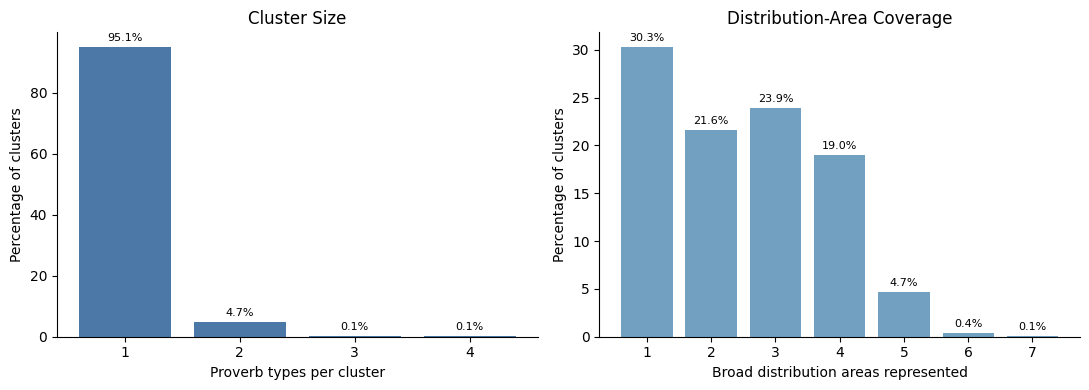

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

plots = [
    (
        axes[0],
        support_distribution,
        "proverb_types",
        "Cluster Size",
        "Proverb types per cluster",
        "#4c78a8",
    ),
    (
        axes[1],
        coverage_distribution,
        "distribution_areas",
        "Distribution-Area Coverage",
        "Broad distribution areas represented",
        "#72a0c1",
    ),
]

for ax, data, x, title, xlabel, color in plots:
    bars = ax.bar(
        data[x].astype(str),
        data["percentage"],
        color=color,
    )

    ax.bar_label(
        bars,
        fmt="%.1f%%",
        padding=3,
        fontsize=8,
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Percentage of clusters")
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

The extractor retained 1,689 of the 1,727 cleaned proverb types. It excluded 34 records whose primary text was not English-ready and four records without distribution metadata.

The retained types produced 1,606 clusters and 4,068 type-to-area attestations. The output is highly fragmented: 1,527 clusters (95.1%) contain only one proverb type. Only 79 clusters contain multiple types, collectively representing 162 proverb types, or 9.6% of the retained input.

The baseline therefore identifies a small number of lexical groupings but does not substantially consolidate the corpus into broader semantic families.

Distribution-area coverage is broader: 69.7% of clusters represent at least two areas and 48.1% represent at least three. However, a singleton cluster can have broad coverage when its single Kuusi type is documented across several areas. High coverage therefore does not demonstrate successful semantic clustering.

The 4,068 type-to-area links are reconstructed from the published complete-membership table and checked against each cluster's recorded attestation support and coverage. Auxiliary coordinate, nested-JSON, theme, and attestation exports were cross-checked during release validation but are not required by the public notebook.

#### 5.2.3 Example clusters and interpretation report

Multi-type clusters are the most relevant outputs for examining whether the extractor groups proverb types that express the same underlying idea.

In [25]:
# keep multi-type clusters and rank them by recurrence
multi_type_clusters = (
    wisdom_clusters.loc[
        multi_type_mask,
        [
            "cluster_id",
            "claim",
            "coverage",
            "support",
            "attestation_support",
            "wisdom_score",
            "theme",
        ],
    ]
    .sort_values(
        ["wisdom_score", "support"],
        ascending=False,
    )
)

# inspect the ten highest-ranked multi-type clusters
display(multi_type_clusters.head(10))

,cluster_id,claim,coverage,support,attestation_support,wisdom_score,theme
0,12,"While the grass grows, the horse starves.",7,2,8,7.6,Fate / Fortune / Opportunity
1,1,Seeing is believing.,6,4,10,7.2,Trust / Honesty / Deception
2,59,"Love me, love my dog.",6,2,7,6.6,Other
3,63,Better A good neighbour at hand than a brother far away.,6,2,7,6.6,Cooperation / Social Support
4,70,Quick at meal quick work.,6,2,9,6.6,Effort / Time / Persistence
5,75,What the heart thinks the tongue speaks.,6,2,6,6.6,Knowledge / Speech / Silence
6,90,Action speaks louder than words.,6,2,6,6.6,Knowledge / Speech / Silence
7,127,"Play, women and wine undo men laughing.",6,2,7,6.6,Other
8,4,"As the question, so the answer.",5,3,6,5.9,Other
9,3,A thousand years hence the river will run as it did.,5,2,6,5.6,Other


In [26]:
# select examples representing different levels of coherence
example_cluster_ids = [1, 4, 8]

# show the summary information for each example cluster
display(
    wisdom_clusters.loc[
        wisdom_clusters["cluster_id"].isin(
            example_cluster_ids
        ),
        [
            "cluster_id",
            "claim",
            "coverage",
            "support",
            "wisdom_score",
            "theme",
        ],
    ].sort_values("cluster_id")
)

# show every proverb type assigned to the example clusters
display(
    wisdom_members.loc[
        wisdom_members["cluster_id"].isin(
            example_cluster_ids
        ),
        [
            "cluster_id",
            "external_id",
            "text",
            "distribution_areas",
        ],
    ].sort_values(
        ["cluster_id", "external_id"]
    )
)

,cluster_id,claim,coverage,support,wisdom_score,theme
1,1,Seeing is believing.,6,4,7.2,Trust / Honesty / Deception
8,4,"As the question, so the answer.",5,3,5.9,Other
84,8,A good deed is soon forgotten.,4,3,4.9,Other


,cluster_id,external_id,text,distribution_areas
176,1,C3g-10,Seeing is believing; feeling is the naked truth,Eastern Europe | Finnish and Baltic Sea cultures | Western Europe and the Americas
747,1,H1d-12,Seeing is believing; feeling is the naked truth,Europe (general) | Sub-Saharan Africa
748,1,H1d-13,Seeing is believing,Europe (general) | Finnish and Baltic Sea cultures
1348,1,M3b-16,Seeing is believing,Europe (general) | Finnish and Baltic Sea cultures | Islamic cultures
1112,4,J1l-22,A stupid question deserves no answer,Europe (general)
1461,4,M6e-12,"As the question, so the answer",Finnish and Baltic Sea cultures | Islamic cultures | Older Asiatic cultures (Kuusi) | Western Europe and the Americas
1462,4,M6e-13,"As the question, so the answer",Europe (general)
361,8,D3g-10,"Long absent, soon forgotten",Global type (Kuusi)
847,8,H3e-19,The dead are soon forgotten,Global type (Kuusi)
919,8,H5h-13,A good deed is soon forgotten,Eastern Europe | Islamic cultures | Western Europe and the Americas


The examples illustrate different levels of semantic coherence:

- **Cluster 1, “Seeing is believing,”** contains four types with almost identical wording and meaning. This is a strong cluster, although it primarily consolidates duplicates or close variants.
- **Cluster 4, “As the question, so the answer,”** also contains “A stupid question deserves no answer.” The proverbs concern the relationship between questions and answers, but they do not express exactly the same judgment.
- **Cluster 8, “A good deed is soon forgotten,”** also contains “Long absent, soon forgotten” and “The dead are soon forgotten.” The repeated phrase creates a lexical match, but the proverbs describe different situations and practical meanings.

The baseline can therefore identify close formulations, but surface similarity can also group proverbs that do not express the same underlying wisdom.

#### Deterministic theme labels

The interpretation report assigns each cluster to the first predefined theme whose keywords match its representative claim. These themes are navigation aids rather than validated semantic interpretations.

In [27]:
# count the clusters assigned to each keyword-based theme
theme_summary = (
    wisdom_clusters["theme"]
    .value_counts()
    .rename_axis("theme")
    .reset_index(name="clusters")
)

# calculate each theme's share of all clusters
theme_summary["percentage"] = (
    100
    * theme_summary["clusters"]
    / len(wisdom_clusters)
).round(1)

display(theme_summary)

,theme,clusters,percentage
0,Other,1110,69.1
1,Family / Kinship / Obligation,123,7.7
2,Prudence / Risk & Uncertainty,115,7.2
3,Trust / Honesty / Deception,76,4.7
4,Effort / Time / Persistence,55,3.4
5,Knowledge / Speech / Silence,53,3.3
6,Cooperation / Social Support,51,3.2
7,Fate / Fortune / Opportunity,23,1.4


Most clusters, 1,110 of 1,606 (69.1%), were assigned to `Other`, indicating that the keyword rules provide limited thematic coverage.

Some assignments are plausible:

| Representative claim | Assigned theme |
|---|---|
| Seeing is believing. | Trust / Honesty / Deception |
| Time and tide wait for no man. | Effort / Time / Persistence |

Others are misleading:

| Representative claim | Assigned theme |
|---|---|
| The hasty bitch brings forth blind whelps. | Cooperation / Social Support |
| A bribe enters without knocking. | Family / Kinship / Obligation |
| So many men, so many minds; so many dogs, so many kinds. | Family / Kinship / Obligation |
| You must learn to creep before you go. | Knowledge / Speech / Silence |

A matching keyword may occur in a proverb without representing its subject or practical meaning. The interpretation report is therefore useful for browsing and error analysis, but it should not be treated as an automatic semantic interpretation of the corpus.

#### 5.2.4 Manual evaluation

A formal manual audit of the 79 multi-type clusters was not completed in the current analysis. The qualitative inspection in Section 5.3 illustrates several successful and unsuccessful groupings but should not be interpreted as a numerical estimate of overall cluster quality.

Future evaluation could rate a reproducible sample, or all 79 multi-type clusters, using the Wisdom Extractor audit scale of `pure`, `mostly`, `mixed`, or `junk`.

#### 5.2.5 Findings and limitations

The Wisdom Extractor provides a reproducible lexical baseline for organizing the Kuusi corpus, but it does not yet extract general pieces of wisdom in a strong semantic sense.

The main findings are:

1. **The output is highly fragmented.** At $\tau = 0.35$, 95.1% of clusters contain only one proverb type.

2. **Strong clusters are usually lexically close.** Successful groupings primarily contain duplicates, minor wording changes, or close paraphrases.

3. **Lexical overlap can produce false groupings.** Proverbs may share a phrase or sentence structure while expressing different situations, judgments, or advice.

4. **Coverage does not establish universality.** Coverage counts broad and sometimes overlapping Kuusi distribution areas rather than independent cultures, languages, speakers, or observed uses.

5. **The wisdom score measures recurrence.** It does not measure semantic coherence, truth, usefulness, or wisdom quality.

6. **Canonical claims are not complete meaning representations.** The normalization procedure preserves much of the original wording and does not reliably translate figurative proverbs into explicit interpretations.

7. **The keyword themes are weak semantic approximations.** They assign 69.1% of clusters to `Other` and produce several clear misclassifications.

8. **Manual evaluation remains necessary.** Support, coverage, and wisdom score cannot establish that cluster members express the same underlying idea.

The extractor is therefore most useful for lexical retrieval, duplicate detection, candidate-pair generation, and error analysis. A stronger semantic approach would need to represent the situation described, the recommended action or judgment, and the expected consequence. Human-reviewed must-link and cannot-link pairs could then be used to evaluate or constrain later clustering methods.

### 5.3 Unconstrained LLM category induction

#### 5.3.1 Purpose and provenance

This exploratory experiment asked whether an unconstrained LLM could induce meaningful semantic categories without receiving the Kuusi taxonomy or a theory-guided codebook. It was run through the **ChatGPT free tier on a new account**. The project notes call the system `GPT5.5`, but no saved product metadata verifies that underlying model; the exact model is therefore **unverified**.

The classifications are precomputed experimental outputs, not validated ground truth or evidence of general model performance.

In [28]:
UNCONSTRAINED_LLM_DIR = DATA_DIR / "unconstrained_llms"
LLM_INPUT_PATH = UNCONSTRAINED_LLM_DIR / "llm_text_input.csv"
LLM_OUTPUT_PATH = UNCONSTRAINED_LLM_DIR / "categorized_texts.csv"
LLM_CATEGORY_NOTES_PATH = UNCONSTRAINED_LLM_DIR / "categories.txt"

for required_path in (
    LLM_INPUT_PATH,
    LLM_OUTPUT_PATH,
    LLM_CATEGORY_NOTES_PATH,
):
    if not required_path.is_file():
        raise FileNotFoundError(f"Required experiment file not found: {required_path}")
llm_input_raw = pd.read_csv(LLM_INPUT_PATH, dtype={"id": "string"})
llm_output_raw = pd.read_csv(LLM_OUTPUT_PATH, dtype={"id": "string"})
llm_category_notes = LLM_CATEGORY_NOTES_PATH.read_text(encoding="utf-8")

assert list(llm_input_raw.columns) == ["id", "text"]
assert list(llm_output_raw.columns) == ["id", "category_id"]
assert len(llm_input_raw) == 1_727
assert len(llm_output_raw) == 1_727

source_file_audit = pd.DataFrame([
    {
        "file": path.relative_to(PROJECT_ROOT).as_posix(),
        "rows": len(frame) if frame is not None else pd.NA,
        "columns": ", ".join(frame.columns) if frame is not None else "category definitions and prompt",
        "sha256": file_sha256(path),
    }
    for path, frame in [
        (LLM_INPUT_PATH, llm_input_raw),
        (LLM_OUTPUT_PATH, llm_output_raw),
        (LLM_CATEGORY_NOTES_PATH, None),
    ]
])

schema_audit = pd.DataFrame([
    {
        "file": path.name,
        "column": column,
        "loaded_dtype": str(frame[column].dtype),
        "missing_values": int(frame[column].isna().sum()),
    }
    for path, frame in [
        (LLM_INPUT_PATH, llm_input_raw),
        (LLM_OUTPUT_PATH, llm_output_raw),
    ]
    for column in frame.columns
])

display(source_file_audit)
display(schema_audit)

,file,rows,columns,sha256
0,data/unconstrained_llms/llm_text_input.csv,1727,"id, text",9117cd1613d0cd8fc6c44f579c3c352f6abeae6368712a6a5ac78e8596f1e903
1,data/unconstrained_llms/categorized_texts.csv,1727,"id, category_id",e50c098acda73c7bcfeb98f153206d603f15255b8a48c524840a082200a4fd3a
2,data/unconstrained_llms/categories.txt,<NA>,category definitions and prompt,ccebc843d93d902bda667313cdf639b786eb04a71728454545586a60f522ee5c


,file,column,loaded_dtype,missing_values
0,llm_text_input.csv,id,string,4
1,llm_text_input.csv,text,object,0
2,categorized_texts.csv,id,string,4
3,categorized_texts.csv,category_id,int64,0


#### 5.3.2 Prompt and retained output

The 1,727-row `llm_text_input.csv` file, containing `id` and English proverb `text`, was attached to ChatGPT. The prompt preserved in `categories.txt` was:

> The attached CSV contains English-language texts. Group them into meaningful categories based on their meanings. Choose the categories yourself, and return a CSV showing the ID and assigned category for every text. Also provide a brief name and description for each category.

The retained response has one `category_id` for every input row. Category names and descriptions were saved separately in `categories.txt`. No record-level rationale or confidence field was retained, so individual assignments and model uncertainty cannot be audited from these files.

In [29]:
EXPECTED_OUTPUT_ROWS = 1_727
EXPECTED_IDENTIFIED_ROWS = 1_723
EXPECTED_UNIDENTIFIED_ROWS = 4
VALID_CATEGORY_IDS = set(range(10))


def normalize_source_identifier(values):
    """Normalize source IDs without changing the original column."""
    normalized = values.astype("string").str.strip()
    normalized = normalized.mask(normalized.eq(""))
    return normalized.str.replace(r"^(\d+)\.0$", r"\1", regex=True)


llm_input = llm_input_raw.copy()
llm_output = llm_output_raw.copy()
llm_input["source_id_normalized"] = normalize_source_identifier(llm_input["id"])
llm_output["source_id_normalized"] = normalize_source_identifier(llm_output["id"])

category_numeric = pd.to_numeric(llm_output["category_id"], errors="coerce")
assert category_numeric.notna().all(), "Every output must have a category label."
assert category_numeric.eq(category_numeric.astype(int)).all(), "Category labels must be integers."
llm_output["category_id_validated"] = category_numeric.astype("Int64")
assert set(llm_output["category_id_validated"].unique()) <= VALID_CATEGORY_IDS

identified_input = llm_input.loc[
    llm_input["source_id_normalized"].notna(),
    ["source_id_normalized", "text"],
].copy()
identified_output = llm_output.loc[
    llm_output["source_id_normalized"].notna(),
    ["source_id_normalized", "category_id_validated"],
].copy()

assert len(llm_output) == EXPECTED_OUTPUT_ROWS
assert len(identified_output) == EXPECTED_IDENTIFIED_ROWS
assert llm_output["source_id_normalized"].isna().sum() == EXPECTED_UNIDENTIFIED_ROWS
assert len(identified_input) == EXPECTED_IDENTIFIED_ROWS
assert llm_input["source_id_normalized"].isna().sum() == EXPECTED_UNIDENTIFIED_ROWS
assert not identified_output["source_id_normalized"].duplicated().any()
assert not identified_input["source_id_normalized"].duplicated().any()
assert set(identified_output["source_id_normalized"]) == set(identified_input["source_id_normalized"])

input_output_join = identified_output.merge(
    identified_input,
    on="source_id_normalized",
    how="left",
    validate="one_to_one",
    indicator="_input_join",
)
assert len(input_output_join) == EXPECTED_IDENTIFIED_ROWS
assert input_output_join["_input_join"].eq("both").all()

corpus_for_join = kuusi.copy()
corpus_for_join["source_id_normalized"] = normalize_source_identifier(
    corpus_for_join["source_id"]
)
identified_corpus = corpus_for_join.loc[
    corpus_for_join["source_id_normalized"].notna()
].copy()
assert len(identified_corpus) == EXPECTED_IDENTIFIED_ROWS
assert not identified_corpus["source_id_normalized"].duplicated().any()

record_linked_results = identified_output.merge(
    identified_corpus,
    on="source_id_normalized",
    how="left",
    validate="one_to_one",
    indicator="_corpus_join",
)
assert len(record_linked_results) == EXPECTED_IDENTIFIED_ROWS
assert record_linked_results["_corpus_join"].eq("both").all()
assert record_linked_results["kuusi_id"].notna().all()
assert not record_linked_results["kuusi_id"].duplicated().any()

blank_input_indices = llm_input.index[llm_input["source_id_normalized"].isna()]
blank_output_indices = llm_output.index[llm_output["source_id_normalized"].isna()]
blank_input_evidence_rows = []
for input_index in blank_input_indices:
    input_text = llm_input.at[input_index, "text"]
    exact_matches = kuusi.loc[
        kuusi["proverb_primary_en"].eq(input_text),
        ["kuusi_id", "source_id"],
    ]
    blank_input_evidence_rows.append({
        "input_csv_row": int(input_index + 2),
        "input_text": input_text,
        "exact_corpus_text_matches": len(exact_matches),
        "candidate_kuusi_id": (
            exact_matches.iloc[0]["kuusi_id"] if len(exact_matches) == 1 else pd.NA
        ),
        "candidate_source_id": (
            exact_matches.iloc[0]["source_id"] if len(exact_matches) == 1 else pd.NA
        ),
    })

blank_input_evidence = pd.DataFrame(blank_input_evidence_rows)
assert len(blank_input_evidence) == EXPECTED_UNIDENTIFIED_ROWS
assert blank_input_evidence["exact_corpus_text_matches"].eq(1).all()

blank_output_audit = pd.DataFrame({
    "output_csv_row": [int(index + 2) for index in blank_output_indices],
    "category_id": llm_output.loc[blank_output_indices, "category_id_validated"].to_list(),
    "stable_record_field_retained": "none",
    "record_link_status": "unidentified; excluded from record-level joins",
})

same_blank_row_positions = blank_input_indices.equals(blank_output_indices)
identified_positions = (
    llm_input["source_id_normalized"].notna()
    & llm_output["source_id_normalized"].notna()
)
identified_ids_agree_by_position = llm_input.loc[
    identified_positions, "source_id_normalized"
].equals(llm_output.loc[identified_positions, "source_id_normalized"] )

identifier_audit = pd.DataFrame({
    "check": [
        "Total output rows",
        "Outputs with stable identifiers",
        "Outputs with blank identifiers",
        "Invalid or missing category labels",
        "Duplicate identified output IDs",
        "Identified output IDs absent from input",
        "Identified output IDs absent from corpus",
        "One-to-one record-level joins",
    ],
    "expected": [1_727, 1_723, 4, 0, 0, 0, 0, 1_723],
    "observed": [
        len(llm_output),
        len(identified_output),
        llm_output["source_id_normalized"].isna().sum(),
        (
            llm_output["category_id_validated"].isna().sum()
            + (~llm_output["category_id_validated"].isin(VALID_CATEGORY_IDS)).sum()
        ),
        identified_output["source_id_normalized"].duplicated().sum(),
        len(set(identified_output["source_id_normalized"]) - set(identified_input["source_id_normalized"])),
        len(set(identified_output["source_id_normalized"]) - set(identified_corpus["source_id_normalized"])),
        len(record_linked_results),
    ],
})
identifier_audit["passed"] = identifier_audit["observed"].eq(identifier_audit["expected"])
assert identifier_audit["passed"].all()

display(identifier_audit)
display(blank_input_evidence)
display(blank_output_audit)
print(f"Blank rows occupy the same input/output positions (supporting evidence only): {same_blank_row_positions}")
print(f"The 1,723 retained identifiers also agree by position (not used as the join key): {identified_ids_agree_by_position}")

,check,expected,observed,passed
0,Total output rows,1727,1727,True
1,Outputs with stable identifiers,1723,1723,True
2,Outputs with blank identifiers,4,4,True
3,Invalid or missing category labels,0,0,True
4,Duplicate identified output IDs,0,0,True
5,Identified output IDs absent from input,0,0,True
6,Identified output IDs absent from corpus,0,0,True
7,One-to-one record-level joins,1723,1723,True


,input_csv_row,input_text,exact_corpus_text_matches,candidate_kuusi_id,candidate_source_id
0,302,"The camel has his plans, and the camel-driver has his plans",1,D1d-16b,NaN
1,409,A hut of reeds with mirth therein is better than a palace with grief therein,1,D4c-11,NaN
2,547,Ignorance of the law excuses no one,1,F1b-47c,NaN
3,1139,"Follow not truth too near the heels, lest it dash out thy teeth",1,J1k-27,NaN


,output_csv_row,category_id,stable_record_field_retained,record_link_status
0,302,2,none,unidentified; excluded from record-level joins
1,409,5,none,unidentified; excluded from record-level joins
2,547,2,none,unidentified; excluded from record-level joins
3,1139,2,none,unidentified; excluded from record-level joins


Blank rows occupy the same input/output positions (supporting evidence only): True
The 1,723 retained identifiers also agree by position (not used as the join key): True


#### 5.3.3 Treatment of the four blank identifiers

All 1,727 output rows have valid category labels, so the aggregate distribution uses all 1,727. Record-level analysis uses only the 1,723 rows that have unique source identifiers and pass one-to-one joins to both the saved input and the cleaned corpus; the four blank-ID outputs are explicitly excluded.

Each blank-ID **input text** has one exact `proverb_primary_en` match in the cleaned corpus. However, the output file retains no text or other stable field for its blank-ID rows. The blank rows occur at the same positions in the input and output, but position alone is insufficient to assign an output category to a corpus record. The candidate text matches are reported as evidence only; no identifier is imputed and no corrected derivative file is created.

#### 5.3.4 Aggregate and record-linked category summaries

Aggregate category summary: n=1,727 valid outputs.
Record-linked summary: n=1,723; excluded=4 blank-ID outputs.


,category_id,category_name,all_output_count,record_linked_count,unidentified_output_count,all_output_percentage
2,2,Love / Makes,1354,1351,3,78.4
6,6,Man / Wise,92,92,0,5.3
1,1,Good / Better,64,64,0,3.7
5,5,Better / Egg,60,59,1,3.5
4,4,Old / Young,35,35,0,2.0
3,3,Make / Do,31,31,0,1.8
8,8,Does / Want,30,30,0,1.7
7,7,Ill / Speak,27,27,0,1.6
9,9,Time / Cures,22,22,0,1.3
0,0,Small / Great,12,12,0,0.7


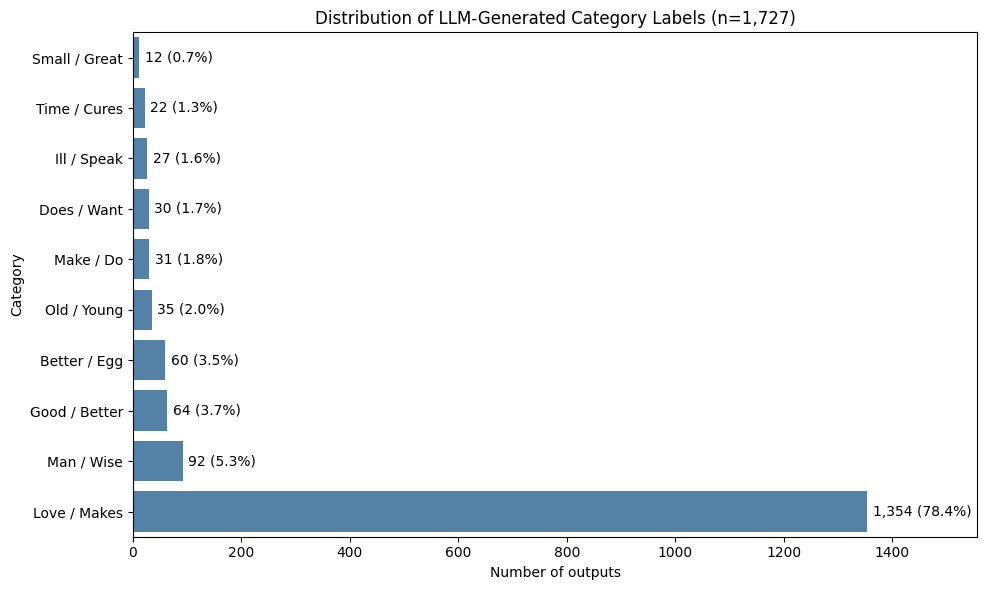

In [30]:
category_names = {
    0: "Small / Great",
    1: "Good / Better",
    2: "Love / Makes",
    3: "Make / Do",
    4: "Old / Young",
    5: "Better / Egg",
    6: "Man / Wise",
    7: "Ill / Speak",
    8: "Does / Want",
    9: "Time / Cures",
}

category_summary = pd.DataFrame({
    "category_id": sorted(VALID_CATEGORY_IDS),
})
category_summary["category_name"] = category_summary["category_id"].map(category_names)

aggregate_counts = (
    llm_output["category_id_validated"]
    .value_counts()
    .rename_axis("category_id")
    .reset_index(name="all_output_count")
)
record_linked_counts = (
    record_linked_results["category_id_validated"]
    .value_counts()
    .rename_axis("category_id")
    .reset_index(name="record_linked_count")
)
unidentified_counts = (
    llm_output.loc[
        llm_output["source_id_normalized"].isna(),
        "category_id_validated",
    ]
    .value_counts()
    .rename_axis("category_id")
    .reset_index(name="unidentified_output_count")
)

category_summary = (
    category_summary
    .merge(aggregate_counts, on="category_id", how="left", validate="one_to_one")
    .merge(record_linked_counts, on="category_id", how="left", validate="one_to_one")
    .merge(unidentified_counts, on="category_id", how="left", validate="one_to_one")
)
count_columns = [
    "all_output_count",
    "record_linked_count",
    "unidentified_output_count",
]
category_summary[count_columns] = category_summary[count_columns].fillna(0).astype(int)
category_summary["all_output_percentage"] = (
    category_summary["all_output_count"] / EXPECTED_OUTPUT_ROWS * 100
).round(1)

assert category_summary["all_output_count"].sum() == EXPECTED_OUTPUT_ROWS
assert category_summary["record_linked_count"].sum() == EXPECTED_IDENTIFIED_ROWS
assert category_summary["unidentified_output_count"].sum() == EXPECTED_UNIDENTIFIED_ROWS
assert (
    category_summary["record_linked_count"]
    + category_summary["unidentified_output_count"]
).equals(category_summary["all_output_count"])

print(f"Aggregate category summary: n={EXPECTED_OUTPUT_ROWS:,} valid outputs.")
print(
    f"Record-linked summary: n={EXPECTED_IDENTIFIED_ROWS:,}; "
    f"excluded={EXPECTED_UNIDENTIFIED_ROWS} blank-ID outputs."
)
display(category_summary.sort_values("all_output_count", ascending=False))

label_distribution_df = category_summary.sort_values("all_output_count")
plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=label_distribution_df,
    x="all_output_count",
    y="category_name",
    color="steelblue",
)
for bar, row in zip(ax.patches, label_distribution_df.itertuples()):
    ax.text(
        bar.get_width() + 10,
        bar.get_y() + bar.get_height() / 2,
        f"{row.all_output_count:,} ({row.all_output_percentage:.1f}%)",
        va="center",
    )

plt.title("Distribution of LLM-Generated Category Labels (n=1,727)")
plt.xlabel("Number of outputs")
plt.ylabel("Category")
plt.xlim(0, label_distribution_df["all_output_count"].max() * 1.15)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "mk_llm_category_graph.png", dpi=300, bbox_inches="tight")
plt.show()

| Category | Name          | Description                                                                    |
| -------: | ------------- | ------------------------------------------------------------------------------ |
|        0 | Small / Great | Texts about size, importance, or relative significance.                        |
|        1 | Good / Better | Texts comparing goodness, improvement, or quality.                             |
|        2 | Love / Makes  | Texts concerning love, relationships, or emotions.                             |
|        3 | Make / Do     | Advice or actions involving doing, making, or behavior.                        |
|        4 | Old / Young   | Texts about age, experience, or generations.                                   |
|        5 | Better / Egg  | Miscellaneous practical sayings (cluster centered on several recurring words). |
|        6 | Man / Wise    | Human nature, wisdom, and personal character.                                  |
|        7 | Ill / Speak   | Speech, communication, and interpersonal conduct.                              |
|        8 | Does / Want   | Desire, intention, and decision-making.                                        |
|        9 | Time / Cures  | Time, patience, and change over time.                                          |

The unconstrained run produced ten categories, but the distribution is extremely imbalanced: category 2 (`Love / Makes`) contains 1,354 of 1,727 outputs (78.4%). Several categories are broad and lexically named, and a label such as `Better / Egg` indicates weak semantic coherence. The categories also mix topics, actions, evaluations, and recurring words.

These results suggest that this particular unconstrained run did not yield a stable or clearly interpretable representation of proverb meaning. That conclusion is limited to this exploratory dataset and procedure. The labels were not independently validated, the exact underlying ChatGPT model was not recorded, four output rows lack stable identifiers, and the retained output contains neither rationales nor confidence values.

## 6. Consolidated findings

### 6.1 Findings across the computational explorations

This project converted the Matti Kuusi proverb typology into a documented, NLP-ready corpus of 1,727 unique proverb types and evaluated several approaches to organizing their meanings.

The main findings are:

1. **The published cleaned dataset supports a reproducible public analysis.** The notebook validates 1,727 records and 36 fields, while `src/kuusi_cleaning.py` documents the cleaning logic. Because the raw JSON is not public, this workflow does not reproduce the complete raw-to-cleaned transformation.

2. **The Kuusi hierarchy is useful but is not a simple semantic ground truth.** It combines themes, structural patterns, motifs, comparisons, and practical classification judgments. It should be treated as a structured reference system rather than as one definitive set of NLP labels.

3. **Lexical and embedding retrieval capture different kinds of proximity.** TF-IDF emphasizes shared words and phrasing, while MiniLM can retrieve broader associations. Neither similarity score establishes semantic equivalence, and the five-anchor comparison is qualitative rather than a performance benchmark.

4. **Lexical clustering identifies close formulations more reliably than shared wisdom.** Wisdom Extractor produced 1,606 clusters, but 95.1% were singletons. Successful multi-type clusters were usually duplicates, minor variants, or close paraphrases.

5. **Coverage does not prove universality.** A proverb type can occur across several broad Kuusi distribution areas, but those areas are overlapping scholarly categories rather than independent cultures, languages, speakers, or observations.

6. **Unconstrained LLM categorization did not produce a stable taxonomy.** Ten categories were produced, but 78.4% of the corpus was placed in one broad category and several labels reflected recurring words rather than coherent meanings.

7. **Explicit prescription can be annotated comparatively reliably within the pilot.** The two human annotators reached 95% agreement and Cohen's $\kappa = 0.798$ on the explicit-prescription versus description distinction.

8. **Implicit prescription is substantially more difficult.** Human agreement was 63% with Cohen's $\kappa = 0.127$, indicating that the construct or codebook was not applied reliably.

9. **Simple supervised models provide a useful diagnostic baseline.** TF-IDF models can test whether explicit prescription is recoverable from lexical form, but the small and imbalanced pilot does not support strong generalization claims.

Taken together, the results suggest that proverb meaning cannot be represented adequately by lexical similarity, one broad topic, or one prescriptive/descriptive label alone. A stronger representation should separate the situation described, the evaluation or consequence, and the behavioural implication.

## 7. Exploratory human–LLM annotation appendix

This exploratory pilot compares two human coders and one LLM on the same 100 proverb-type records. The source CSV files are treated as immutable inputs. All encoding corrections, string-label derivations, and comparisons are performed in memory and joined by `kuusi_id`, never by row order alone.

### 7.1 Source files and original encodings

The files do not all use the primary-label numbers in the same direction. Their original encodings are preserved and documented before normalization:

| Source | Original primary-label encoding | Original implicit-label encoding | Missing labels |
|---|---|---|---|
| P1 | `0 = descriptive`, `1 = prescriptive` | `0 = absent`, `1 = present` | 14 implicit labels were structurally skipped for records P1 marked explicitly prescriptive |
| P2 | `0 = prescriptive`, `1 = descriptive` | `0 = absent`, `1 = present` | None |
| LLM output | `0 = prescriptive`, `1 = descriptive` | `0 = absent`, `1 = present` | None |
| Unlabelled sample and LLM input | Label columns are blank | Label columns are blank | Expected by design |

The study-standardized primary encoding is `0 = prescriptive`, `1 = descriptive`. P1 must therefore be reversed exactly once. To prevent later ambiguity, agreement calculations use descriptive string labels rather than numeric values.

In [31]:
ANNOTATION_DIR = DATA_DIR / "annotations"
EXPECTED_PILOT_RECORDS = 100

annotation_paths = {
    "Human sample": ANNOTATION_DIR / "prescriptive_descriptive_sample_100.csv",
    "P1": ANNOTATION_DIR / "p1_label_100_proverbs.csv",
    "P2": ANNOTATION_DIR / "p2_label_100_proverbs.csv",
    "LLM input": ANNOTATION_DIR / "llm_annotation_input_100.csv",
    "LLM output": ANNOTATION_DIR / "llm_annotation_output_100.csv",
}

missing_annotation_files = [
    str(path) for path in annotation_paths.values() if not path.is_file()
]
if missing_annotation_files:
    raise FileNotFoundError(
        "Missing annotation file(s): "
        + ", ".join(missing_annotation_files)
    )

sample_raw = pd.read_csv(annotation_paths["Human sample"])
p1_raw = pd.read_csv(annotation_paths["P1"])
p2_raw = pd.read_csv(annotation_paths["P2"])
llm_input_raw = pd.read_csv(annotation_paths["LLM input"])
llm_output_raw = pd.read_csv(annotation_paths["LLM output"])

annotation_sources = {
    "Human sample": (sample_raw, "kuusi_id"),
    "P1": (p1_raw, "kuusi_id"),
    "P2": (p2_raw, "kuusi_id"),
    "LLM input": (llm_input_raw, "kuusi_id"),
    "LLM output": (llm_output_raw, "id"),
}

source_audit_rows = []
source_id_sets = {}

for source_name, (source_df, id_column) in annotation_sources.items():
    if len(source_df) != EXPECTED_PILOT_RECORDS:
        raise ValueError(
            f"{source_name} must contain exactly "
            f"{EXPECTED_PILOT_RECORDS} records; found {len(source_df)}."
        )

    identifiers = source_df[id_column].astype("string").str.strip()
    missing_ids = int(identifiers.isna().sum() + identifiers.eq("").sum())
    duplicate_ids = int(identifiers.duplicated().sum())

    if missing_ids or duplicate_ids:
        raise ValueError(
            f"{source_name} has {missing_ids} missing and "
            f"{duplicate_ids} duplicate identifiers."
        )

    source_id_sets[source_name] = set(identifiers)
    source_audit_rows.append({
        "source": source_name,
        "records": len(source_df),
        "unique_identifiers": identifiers.nunique(),
        "missing_identifiers": missing_ids,
        "duplicate_identifiers": duplicate_ids,
    })

reference_ids = source_id_sets["Human sample"]
for source_name, identifiers in source_id_sets.items():
    if identifiers != reference_ids:
        raise ValueError(
            f"{source_name} does not contain the expected identifier set."
        )

reference_text = sample_raw[["kuusi_id", "proverb_primary_en"]]
for source_name, source_df in {
    "P1": p1_raw,
    "P2": p2_raw,
    "LLM input": llm_input_raw,
}.items():
    text_check = reference_text.merge(
        source_df[["kuusi_id", "proverb_primary_en"]],
        on="kuusi_id",
        how="inner",
        suffixes=("_sample", "_source"),
        validate="one_to_one",
    )
    text_mismatches = (
        text_check["proverb_primary_en_sample"]
        != text_check["proverb_primary_en_source"]
    ).sum()
    if len(text_check) != EXPECTED_PILOT_RECORDS or text_mismatches:
        raise ValueError(
            f"{source_name} failed identifier/text alignment."
        )

annotation_source_audit = pd.DataFrame(source_audit_rows)
display(annotation_source_audit)

,source,records,unique_identifiers,missing_identifiers,duplicate_identifiers
0,Human sample,100,100,0,0
1,P1,100,100,0,0
2,P2,100,100,0,0
3,LLM input,100,100,0,0
4,LLM output,100,100,0,0


### 7.2 One-time normalization and alignment

P1’s raw primary label is preserved in `p1_primary_original_value`. The standardized value is then calculated exactly once as `1 - p1_primary_original_value`. An assertion verifies that every original/standardized pair sums to one. P2 and the LLM already use the study-standardized direction and are mapped without reversal.

P1’s 14 missing implicit-prescription values are handled separately. They are retained as missing in `p1_implicit_original_value` and flagged in `p1_implicit_structural_skip`. Because all 14 occur on records P1 marked explicitly prescriptive, the comparison-only string label is derived as `implicit prescription absent` under the pilot codebook. The original missing values remain available and are never overwritten.

In [32]:
PRIMARY_LABELS = {
    0: "prescriptive",
    1: "descriptive",
}
IMPLICIT_LABELS = {
    0: "implicit prescription absent",
    1: "implicit prescription present",
}


def validated_binary_labels(
    series,
    source_name,
    column_name,
    allow_missing=False,
):
    """Return nullable integer labels after validating source values."""
    numeric = pd.to_numeric(series, errors="coerce")
    malformed = series.notna() & numeric.isna()
    invalid_values = set(numeric.dropna().unique()) - {0, 1}

    if malformed.any() or invalid_values:
        raise ValueError(
            f"{source_name}.{column_name} contains invalid labels."
        )
    if not allow_missing and numeric.isna().any():
        raise ValueError(
            f"{source_name}.{column_name} contains missing labels."
        )

    return numeric.astype("Int64")


p1_primary_source = validated_binary_labels(
    p1_raw["prescriptive_or_descriptive"],
    "P1",
    "prescriptive_or_descriptive",
)
p1_implicit_source = validated_binary_labels(
    p1_raw["has_implicit_prescription"],
    "P1",
    "has_implicit_prescription",
    allow_missing=True,
)
p2_primary_source = validated_binary_labels(
    p2_raw["prescriptive_or_descriptive"],
    "P2",
    "prescriptive_or_descriptive",
)
p2_implicit_source = validated_binary_labels(
    p2_raw["has_implicit_prescription"],
    "P2",
    "has_implicit_prescription",
)
llm_primary_source = validated_binary_labels(
    llm_output_raw["prescriptive_or_descriptive"],
    "LLM output",
    "prescriptive_or_descriptive",
)
llm_implicit_source = validated_binary_labels(
    llm_output_raw["has_implicit_prescription"],
    "LLM output",
    "has_implicit_prescription",
)

for source_name, source_df in {
    "Human sample": sample_raw,
    "LLM input": llm_input_raw,
}.items():
    for column in [
        "prescriptive_or_descriptive",
        "has_implicit_prescription",
    ]:
        if source_df[column].notna().any():
            raise ValueError(
                f"{source_name}.{column} should be blank."
            )

p1_normalized = pd.DataFrame({
    "kuusi_id": p1_raw["kuusi_id"].astype("string"),
    "p1_primary_original_value": p1_primary_source,
    "p1_implicit_original_value": p1_implicit_source,
})

# Apply P1's required primary-label reversal exactly once.
p1_normalized["p1_primary_standardized_value"] = (
    1 - p1_normalized["p1_primary_original_value"]
).astype("Int64")

p1_primary_nonmissing = p1_normalized[
    [
        "p1_primary_original_value",
        "p1_primary_standardized_value",
    ]
].dropna()
if not (p1_primary_nonmissing.sum(axis=1) == 1).all():
    raise AssertionError(
        "P1 original and standardized primary values must sum to 1."
    )

p1_normalized["p1_primary_standardized_label"] = (
    p1_normalized["p1_primary_standardized_value"].map(PRIMARY_LABELS)
)
p1_normalized["p1_implicit_structural_skip"] = (
    p1_normalized["p1_implicit_original_value"].isna()
    & p1_normalized["p1_primary_standardized_value"].eq(0)
)

if int(p1_normalized["p1_implicit_structural_skip"].sum()) != 14:
    raise ValueError("Expected 14 documented P1 structural skips.")
if (
    p1_normalized["p1_implicit_original_value"].isna()
    != p1_normalized["p1_implicit_structural_skip"]
).any():
    raise ValueError(
        "P1 has an undocumented missing implicit-prescription label."
    )

p1_normalized["p1_implicit_observed_label"] = (
    p1_normalized["p1_implicit_original_value"].map(IMPLICIT_LABELS)
)
p1_normalized["p1_implicit_comparison_label"] = (
    p1_normalized["p1_implicit_observed_label"].copy()
)
p1_normalized.loc[
    p1_normalized["p1_implicit_structural_skip"],
    "p1_implicit_comparison_label",
] = IMPLICIT_LABELS[0]

p2_normalized = pd.DataFrame({
    "kuusi_id": p2_raw["kuusi_id"].astype("string"),
    "p2_primary_source_value": p2_primary_source,
    "p2_primary_label": p2_primary_source.map(PRIMARY_LABELS),
    "p2_implicit_source_value": p2_implicit_source,
    "p2_implicit_label": p2_implicit_source.map(IMPLICIT_LABELS),
})

llm_normalized = pd.DataFrame({
    "kuusi_id": llm_output_raw["id"].astype("string"),
    "llm_primary_source_value": llm_primary_source,
    "llm_primary_label": llm_primary_source.map(PRIMARY_LABELS),
    "llm_implicit_source_value": llm_implicit_source,
    "llm_implicit_label": llm_implicit_source.map(IMPLICIT_LABELS),
})

print("P1 primary encoding reversed exactly once.")
print(
    "Documented P1 implicit structural skips:",
    int(p1_normalized["p1_implicit_structural_skip"].sum()),
)

P1 primary encoding reversed exactly once.
Documented P1 implicit structural skips: 14


In [33]:
pilot_base = sample_raw[["kuusi_id", "proverb_primary_en"]].copy()
pilot_base["kuusi_id"] = pilot_base["kuusi_id"].astype("string")

human_comparison_df = (
    pilot_base
    .merge(
        p1_normalized,
        on="kuusi_id",
        how="left",
        validate="one_to_one",
        indicator="p1_join_status",
    )
    .merge(
        p2_normalized,
        on="kuusi_id",
        how="left",
        validate="one_to_one",
        indicator="p2_join_status",
    )
)

annotation_comparison_df = human_comparison_df.merge(
    llm_normalized,
    on="kuusi_id",
    how="left",
    validate="one_to_one",
    indicator="llm_join_status",
)

join_audit = pd.DataFrame({
    "source": ["P1", "P2", "LLM output"],
    "matched": [
        int(human_comparison_df["p1_join_status"].eq("both").sum()),
        int(human_comparison_df["p2_join_status"].eq("both").sum()),
        int(annotation_comparison_df["llm_join_status"].eq("both").sum()),
    ],
    "missing_after_join": [
        int(human_comparison_df["p1_join_status"].ne("both").sum()),
        int(human_comparison_df["p2_join_status"].ne("both").sum()),
        int(annotation_comparison_df["llm_join_status"].ne("both").sum()),
    ],
})

if len(annotation_comparison_df) != EXPECTED_PILOT_RECORDS:
    raise ValueError("The aligned pilot must contain exactly 100 records.")
if annotation_comparison_df["kuusi_id"].duplicated().any():
    raise ValueError("Duplicate records remain after annotation joins.")
if join_audit["missing_after_join"].sum() != 0:
    raise ValueError("At least one annotation source failed to align.")

display(join_audit)
display(
    annotation_comparison_df[[
        "kuusi_id",
        "p1_primary_original_value",
        "p1_primary_standardized_value",
        "p1_primary_standardized_label",
        "p2_primary_label",
        "llm_primary_label",
    ]].head()
)

,source,matched,missing_after_join
0,P1,100,0
1,P2,100,0
2,LLM output,100,0


,kuusi_id,p1_primary_original_value,p1_primary_standardized_value,p1_primary_standardized_label,p2_primary_label,llm_primary_label
0,G2a-10b,0,1,descriptive,descriptive,descriptive
1,A3a-25,0,1,descriptive,descriptive,descriptive
2,C6b-25e,0,1,descriptive,descriptive,descriptive
3,M4c-14,0,1,descriptive,descriptive,descriptive
4,C2f-13,0,1,descriptive,descriptive,descriptive


In [34]:
encoding_audit = pd.DataFrame([
    {
        "source": "P1",
        "primary_encoding_in_file": "0 = descriptive; 1 = prescriptive",
        "primary_missing": int(p1_primary_source.isna().sum()),
        "implicit_missing": int(p1_implicit_source.isna().sum()),
        "structural_skips": int(
            p1_normalized["p1_implicit_structural_skip"].sum()
        ),
    },
    {
        "source": "P2",
        "primary_encoding_in_file": "0 = prescriptive; 1 = descriptive",
        "primary_missing": int(p2_primary_source.isna().sum()),
        "implicit_missing": int(p2_implicit_source.isna().sum()),
        "structural_skips": 0,
    },
    {
        "source": "LLM output",
        "primary_encoding_in_file": "0 = prescriptive; 1 = descriptive",
        "primary_missing": int(llm_primary_source.isna().sum()),
        "implicit_missing": int(llm_implicit_source.isna().sum()),
        "structural_skips": 0,
    },
])

display(encoding_audit)

,source,primary_encoding_in_file,primary_missing,implicit_missing,structural_skips
0,P1,0 = descriptive; 1 = prescriptive,0,14,14
1,P2,0 = prescriptive; 1 = descriptive,0,0,0
2,LLM output,0 = prescriptive; 1 = descriptive,0,0,0


### 7.3 Human–human agreement

Agreement is calculated from normalized string labels. Cohen’s kappa is reported only when both compared columns contain more than one observed class.

In [35]:
def agreement_row(
    frame,
    comparison,
    dimension,
    left_column,
    right_column,
    eligible_mask=None,
    exclusion_reason="None",
    notes="",
):
    """Calculate agreement after explicit eligibility and missingness checks."""
    if eligible_mask is None:
        eligible_mask = pd.Series(True, index=frame.index)
    eligible_mask = eligible_mask.fillna(False).astype(bool)

    valid_mask = (
        eligible_mask
        & frame[left_column].notna()
        & frame[right_column].notna()
    )
    valid = frame.loc[valid_mask, [left_column, right_column]]

    if valid.empty:
        raise ValueError(f"No valid records for {comparison}: {dimension}.")

    kappa_is_appropriate = (
        valid[left_column].nunique() > 1
        and valid[right_column].nunique() > 1
    )
    kappa = (
        cohen_kappa_score(valid[left_column], valid[right_column])
        if kappa_is_appropriate
        else float("nan")
    )

    return {
        "comparison": comparison,
        "dimension": dimension,
        "n": len(valid),
        "percent_agreement": round(
            float((valid[left_column] == valid[right_column]).mean() * 100),
            1,
        ),
        "cohens_kappa": round(float(kappa), 3),
        "kappa_appropriate": kappa_is_appropriate,
        "excluded": int(len(frame) - len(valid)),
        "exclusion_reason": exclusion_reason,
        "notes": notes,
    }


human_agreement_df = pd.DataFrame([
    agreement_row(
        annotation_comparison_df,
        comparison="P1 vs P2",
        dimension="Prescriptive/descriptive",
        left_column="p1_primary_standardized_label",
        right_column="p2_primary_label",
    ),
    agreement_row(
        annotation_comparison_df,
        comparison="P1 vs P2",
        dimension="Implicit prescription",
        left_column="p1_implicit_comparison_label",
        right_column="p2_implicit_label",
        notes=(
            "P1 retained 14 original structural skips; comparison labels "
            "are derived as implicit prescription absent for those explicit "
            "prescriptions."
        ),
    ),
])

prior_human_results = pd.DataFrame({
    "dimension": [
        "Prescriptive/descriptive",
        "Implicit prescription",
    ],
    "prior_percent_agreement": [95.0, 63.0],
    "prior_cohens_kappa": [0.798, 0.127],
})
human_prior_check = human_agreement_df.merge(
    prior_human_results,
    on="dimension",
    validate="one_to_one",
)
human_prior_check["reproduces_prior_result"] = (
    human_prior_check["percent_agreement"].eq(
        human_prior_check["prior_percent_agreement"]
    )
    & (
        human_prior_check["cohens_kappa"]
        - human_prior_check["prior_cohens_kappa"]
    ).abs().le(0.001)
)

if not human_prior_check["reproduces_prior_result"].all():
    raise ValueError(
        "Fresh human-agreement calculations do not reproduce the prior results."
    )

display(human_agreement_df)
display(human_prior_check[[
    "dimension",
    "reproduces_prior_result",
]])

,comparison,dimension,n,percent_agreement,cohens_kappa,kappa_appropriate,excluded,exclusion_reason,notes
0,P1 vs P2,Prescriptive/descriptive,100,95.0,0.798,True,0,None,
1,P1 vs P2,Implicit prescription,100,63.0,0.127,True,0,None,P1 retained 14 original structural skips; comparison labels are derived as implicit prescription absent for those explicit prescriptions.


,dimension,reproduces_prior_result
0,Prescriptive/descriptive,True
1,Implicit prescription,True


The fresh calculations reproduce the prior human–human results. Prescriptive/descriptive agreement is 95% with Cohen’s κ = 0.798, supporting the reliability of that distinction within this 100-item pilot. Implicit-prescription agreement is 63% with κ = 0.127. The low kappa indicates that the implicit-prescription construct or codebook was not applied reliably, despite raw agreement above 60%. These pilot results should not be generalized beyond the sampled records.

### 7.4 LLM annotation procedure

The LLM received the same 100 `kuusi_id` records through `llm_annotation_input_100.csv`. That input contains identifiers and proverb text but no human labels. The output is aligned to the human files by identifier. The experiment used the ChatGPT free tier; the exact underlying model is unverified.

In [36]:
llm_source_quality = pd.Series({
    "input_rows": len(llm_input_raw),
    "output_rows": len(llm_output_raw),
    "input_missing_ids": int(llm_input_raw["kuusi_id"].isna().sum()),
    "output_missing_ids": int(llm_output_raw["id"].isna().sum()),
    "output_duplicate_ids": int(llm_output_raw["id"].duplicated().sum()),
    "output_missing_primary_labels": int(llm_primary_source.isna().sum()),
    "output_missing_implicit_labels": int(llm_implicit_source.isna().sum()),
    "unique_confidence_values": llm_output_raw["confidence"].nunique(),
    "unique_rationales": llm_output_raw["brief_rationale"].nunique(),
})

display(llm_source_quality.to_frame("value"))

,value
input_rows,100
output_rows,100
input_missing_ids,0
output_missing_ids,0
output_duplicate_ids,0
output_missing_primary_labels,0
output_missing_implicit_labels,0
unique_confidence_values,1
unique_rationales,1


#### Prompt used for the pilot

The following instructions were provided through the ChatGPT free tier; the exact underlying model is unverified.
    
```text
You are independently coding short English texts.
For each text, assign two binary labels.
    1. prescriptive_or_descriptive
    - 0 = explicitly prescriptive: directly gives advice, a command,
      prohibition, recommendation, or rule about what someone should do.
    - 1 = descriptive: states a relationship, condition, comparison,
      consequence, tendency, or state without directly instructing someone.
    Judge this label based on the text's surface form.
    2. has_implicit_prescription
    - 1 = although the text is descriptive, it supports reasonably clear
      behavioural guidance about what someone should do, avoid, prefer,
      or prepare for.
    - 0 = no clear implicit behavioural guidance is supported.
    An implicit prescription must be supported by at least one of:
    - a positive or negative consequence;
    - an evaluated comparison;
    - a normative claim.
    Do not assign an implicit prescription merely because any statement could
    be rewritten as advice. If prescriptive_or_descriptive is 0, normally assign
    has_implicit_prescription as 0 because the advice is explicit.
    
    Use only the supplied text. Do not use existing classifications or invent
    cultural context.
    
    Return a CSV containing:
    id,prescriptive_or_descriptive,has_implicit_prescription,confidence,brief_rationale
```

- Format inspired by: https://khnsakhnm.medium.com/part-2-how-i-annotated-800-reddit-posts-and-used-an-llm-to-check-my-work-1656095e2119

#### Operational decision rules used in the pilot

| Feature in the text | Assigned label |
|---------------------|----------------|
| Contains explicit directive language such as **should, must, ought, need to, never, always, don't, do not, avoid, remember, be sure, let, keep** | `prescriptive_or_descriptive = 0` (explicitly prescriptive) |
| Otherwise | `prescriptive_or_descriptive = 1` (descriptive) |
| If explicit prescription detected | `has_implicit_prescription = 0` (because the advice is already explicit) |
| If descriptive but contains evaluative or consequence markers such as **better, worse, more than, less than, leads to, causes, results in, because, if..., then..., danger, benefit, success, failure** | `has_implicit_prescription = 1` |
| Otherwise | `has_implicit_prescription = 0` |

### 7.5 LLM output and comparison subsets

In [37]:
primary_humans_agree = (
    annotation_comparison_df["p1_primary_standardized_label"]
    == annotation_comparison_df["p2_primary_label"]
)
implicit_humans_agree = (
    annotation_comparison_df["p1_implicit_comparison_label"]
    == annotation_comparison_df["p2_implicit_label"]
)

# Define shared human labels only where P1 and P2 agree.
annotation_comparison_df["human_primary_agreed_label"] = pd.NA
annotation_comparison_df.loc[
    primary_humans_agree,
    "human_primary_agreed_label",
] = annotation_comparison_df.loc[
    primary_humans_agree,
    "p1_primary_standardized_label",
]

annotation_comparison_df["human_implicit_agreed_label"] = pd.NA
annotation_comparison_df.loc[
    implicit_humans_agree,
    "human_implicit_agreed_label",
] = annotation_comparison_df.loc[
    implicit_humans_agree,
    "p1_implicit_comparison_label",
]

human_agreement_subset_summary = pd.DataFrame({
    "dimension": [
        "Prescriptive/descriptive",
        "Implicit prescription",
    ],
    "human_agreement_subset_n": [
        int(primary_humans_agree.sum()),
        int(implicit_humans_agree.sum()),
    ],
    "excluded_human_disagreements": [
        int((~primary_humans_agree).sum()),
        int((~implicit_humans_agree).sum()),
    ],
})

display(human_agreement_subset_summary)

,dimension,human_agreement_subset_n,excluded_human_disagreements
0,Prescriptive/descriptive,95,5
1,Implicit prescription,63,37


In [38]:
llm_joint_label_table = pd.crosstab(
    annotation_comparison_df["llm_primary_label"],
    annotation_comparison_df["llm_implicit_label"],
    rownames=["LLM primary label"],
    colnames=["LLM implicit-prescription label"],
    margins=True,
)

llm_primary_distribution = (
    annotation_comparison_df["llm_primary_label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
llm_primary_distribution["percentage"] = (
    llm_primary_distribution["count"]
    / len(annotation_comparison_df)
    * 100
)

llm_implicit_distribution = (
    annotation_comparison_df["llm_implicit_label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
llm_implicit_distribution["percentage"] = (
    llm_implicit_distribution["count"]
    / len(annotation_comparison_df)
    * 100
)

display(llm_joint_label_table)

LLM implicit-prescription label,implicit prescription absent,implicit prescription present,All
LLM primary label,,,
descriptive,66,25,91
prescriptive,9,0,9
All,75,25,100


In [39]:
llm_comparison_specs = [
    {
        "comparison": "LLM vs P1",
        "dimension": "Prescriptive/descriptive",
        "left_column": "llm_primary_label",
        "right_column": "p1_primary_standardized_label",
        "eligible_mask": None,
        "exclusion_reason": "None",
    },
    {
        "comparison": "LLM vs P1",
        "dimension": "Implicit prescription",
        "left_column": "llm_implicit_label",
        "right_column": "p1_implicit_comparison_label",
        "eligible_mask": None,
        "exclusion_reason": "None",
        "notes": (
            "P1 retained 14 original structural skips; the comparison-only "
            "label follows the codebook rule for explicit prescriptions."
        ),
    },
    {
        "comparison": "LLM vs P2",
        "dimension": "Prescriptive/descriptive",
        "left_column": "llm_primary_label",
        "right_column": "p2_primary_label",
        "eligible_mask": None,
        "exclusion_reason": "None",
    },
    {
        "comparison": "LLM vs P2",
        "dimension": "Implicit prescription",
        "left_column": "llm_implicit_label",
        "right_column": "p2_implicit_label",
        "eligible_mask": None,
        "exclusion_reason": "None",
    },
    {
        "comparison": "LLM vs human-agreement subset",
        "dimension": "Prescriptive/descriptive",
        "left_column": "llm_primary_label",
        "right_column": "human_primary_agreed_label",
        "eligible_mask": primary_humans_agree,
        "exclusion_reason": "Excluded 5 records where P1 and P2 disagreed",
    },
    {
        "comparison": "LLM vs human-agreement subset",
        "dimension": "Implicit prescription",
        "left_column": "llm_implicit_label",
        "right_column": "human_implicit_agreed_label",
        "eligible_mask": implicit_humans_agree,
        "exclusion_reason": "Excluded 37 records where P1 and P2 disagreed",
        "notes": (
            "The human subset uses the derived P1 comparison label while "
            "retaining P1's original structural skips separately."
        ),
    },
]

p1_primary_columns_used = {
    spec["right_column"]
    for spec in llm_comparison_specs
    if spec["comparison"] == "LLM vs P1"
    and spec["dimension"] == "Prescriptive/descriptive"
}
if p1_primary_columns_used != {"p1_primary_standardized_label"}:
    raise AssertionError(
        "LLM-versus-P1 must use P1's standardized primary label."
    )

llm_agreement_df = pd.DataFrame([
    agreement_row(
        annotation_comparison_df,
        comparison=spec["comparison"],
        dimension=spec["dimension"],
        left_column=spec["left_column"],
        right_column=spec["right_column"],
        eligible_mask=spec["eligible_mask"],
        exclusion_reason=spec["exclusion_reason"],
        notes=spec.get("notes", ""),
    )
    for spec in llm_comparison_specs
])

display(llm_agreement_df)

,comparison,dimension,n,percent_agreement,cohens_kappa,kappa_appropriate,excluded,exclusion_reason,notes
0,LLM vs P1,Prescriptive/descriptive,100,91.0,0.561,True,0,None,
1,LLM vs P1,Implicit prescription,100,68.0,0.210,True,0,None,P1 retained 14 original structural skips; the comparison-only label follows the codebook rule for explicit prescriptions.
2,LLM vs P2,Prescriptive/descriptive,100,88.0,0.437,True,0,None,
3,LLM vs P2,Implicit prescription,100,61.0,0.025,True,0,None,
4,LLM vs human-agreement subset,Prescriptive/descriptive,95,91.6,0.555,True,5,Excluded 5 records where P1 and P2 disagreed,
5,LLM vs human-agreement subset,Implicit prescription,63,73.0,0.285,True,37,Excluded 37 records where P1 and P2 disagreed,The human subset uses the derived P1 comparison label while retaining P1's original structural skips separately.


In [40]:
expected_llm_comparison_sizes = pd.DataFrame({
    "comparison": [
        "LLM vs P1",
        "LLM vs P1",
        "LLM vs P2",
        "LLM vs P2",
        "LLM vs human-agreement subset",
        "LLM vs human-agreement subset",
    ],
    "dimension": [
        "Prescriptive/descriptive",
        "Implicit prescription",
        "Prescriptive/descriptive",
        "Implicit prescription",
        "Prescriptive/descriptive",
        "Implicit prescription",
    ],
    "expected_n": [100, 100, 100, 100, 95, 63],
    "expected_excluded": [0, 0, 0, 0, 5, 37],
})

llm_comparison_size_check = llm_agreement_df.merge(
    expected_llm_comparison_sizes,
    on=["comparison", "dimension"],
    validate="one_to_one",
)
llm_comparison_size_check["valid_size"] = (
    llm_comparison_size_check["n"].eq(
        llm_comparison_size_check["expected_n"]
    )
    & llm_comparison_size_check["excluded"].eq(
        llm_comparison_size_check["expected_excluded"]
    )
)

if not llm_comparison_size_check["valid_size"].all():
    raise ValueError("Unexpected LLM comparison sample size.")

display(llm_comparison_size_check[[
    "comparison",
    "dimension",
    "n",
    "excluded",
    "valid_size",
]])

,comparison,dimension,n,excluded,valid_size
0,LLM vs P1,Prescriptive/descriptive,100,0,True
1,LLM vs P1,Implicit prescription,100,0,True
2,LLM vs P2,Prescriptive/descriptive,100,0,True
3,LLM vs P2,Implicit prescription,100,0,True
4,LLM vs human-agreement subset,Prescriptive/descriptive,95,5,True
5,LLM vs human-agreement subset,Implicit prescription,63,37,True


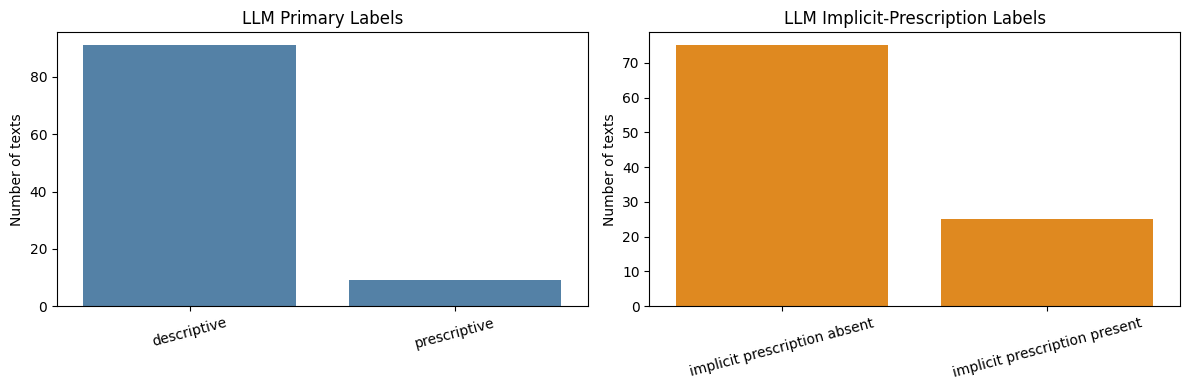

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=llm_primary_distribution,
    x="label",
    y="count",
    color="steelblue",
    ax=axes[0]
)

sns.barplot(
    data=llm_implicit_distribution,
    x="label",
    y="count",
    color="darkorange",
    ax=axes[1]
)

axes[0].set_title("LLM Primary Labels")
axes[1].set_title("LLM Implicit-Prescription Labels")

for axis in axes:
    axis.set_xlabel("")
    axis.set_ylabel("Number of texts")
    axis.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [42]:
pilot_agreement_summary = pd.concat(
    [human_agreement_df, llm_agreement_df],
    ignore_index=True,
)

display(pilot_agreement_summary[[
    "comparison",
    "dimension",
    "n",
    "percent_agreement",
    "cohens_kappa",
    "excluded",
    "exclusion_reason",
]])

,comparison,dimension,n,percent_agreement,cohens_kappa,excluded,exclusion_reason
0,P1 vs P2,Prescriptive/descriptive,100,95.0,0.798,0,None
1,P1 vs P2,Implicit prescription,100,63.0,0.127,0,None
2,LLM vs P1,Prescriptive/descriptive,100,91.0,0.561,0,None
3,LLM vs P1,Implicit prescription,100,68.0,0.210,0,None
4,LLM vs P2,Prescriptive/descriptive,100,88.0,0.437,0,None
5,LLM vs P2,Implicit prescription,100,61.0,0.025,0,None
6,LLM vs human-agreement subset,Prescriptive/descriptive,95,91.6,0.555,5,Excluded 5 records where P1 and P2 disagreed
7,LLM vs human-agreement subset,Implicit prescription,63,73.0,0.285,37,Excluded 37 records where P1 and P2 disagreed


The LLM comparisons are exploratory checks against two individual coders and against dimension-specific subsets where the humans agree. Human disagreements are excluded from the corresponding agreement-subset comparison; no consensus label is invented. Percent agreement and kappa describe this 100-item pilot only and do not establish general model performance. High human agreement on the prescriptive/descriptive distinction supports that distinction within the pilot, while low human kappa for implicit prescription shows that the construct or codebook was not applied reliably.

### 7.6 Supplementary proof-of-concept baseline

A small supervised baseline was used to test whether explicit prescription can be detected from the English surface form of a proverb.

The target is:

- `0`: explicitly prescriptive
- `1`: descriptive in surface form

Only the 95 examples on which both human annotators agreed are included. The implicit-prescription label is excluded because its inter-annotator agreement was not sufficiently reliable.

This experiment compares a majority-class baseline with TF-IDF and logistic regression. It is intended as a proof of concept rather than a final classifier.

In [43]:
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_validate,
)
from sklearn.pipeline import Pipeline

# Retain only the dimension-specific subset where the two humans agree.
# This uses P1's once-standardized string label, never P1's raw value.
consensus_df = annotation_comparison_df.loc[
    annotation_comparison_df["p1_primary_standardized_label"].eq(
        annotation_comparison_df["p2_primary_label"]
    ),
    [
        "kuusi_id",
        "proverb_primary_en",
        "p1_primary_standardized_label",
    ],
].rename(columns={
    "p1_primary_standardized_label": "human_agreed_label",
}).copy()

consensus_df["label"] = consensus_df["human_agreed_label"].map({
    "prescriptive": 0,
    "descriptive": 1,
}).astype(int)
assert len(consensus_df) == 95
assert consensus_df["label"].value_counts().to_dict() == {1: 83, 0: 12}

X = consensus_df["proverb_primary_en"].fillna("")
y = consensus_df["label"]

print("Consensus records:", len(consensus_df))
display(
    consensus_df["label"]
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Explicit prescription",
        1: "Description",
    })
    .to_frame("count")
)

Consensus records: 95


,count
label,
Explicit prescription,12
Description,83


Because the dataset contains 12 explicit prescriptions and 83 descriptions, ordinary accuracy is potentially misleading. A model predicting every item as descriptive would achieve approximately 87% accuracy while identifying no explicit prescriptions.

Macro-F1 and balanced accuracy are therefore treated as the primary metrics.

In [44]:
RANDOM_STATE = 42

models = {
    "Majority class": DummyClassifier(
        strategy="most_frequent"
    ),
    "TF-IDF + logistic regression": Pipeline([
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=2,
                sublinear_tf=True,
            ),
        ),
        (
            "model",
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                random_state=RANDOM_STATE,
            ),
        ),
    ]),
}

cv = RepeatedStratifiedKFold(
    n_splits=5,
    n_repeats=10,
    random_state=RANDOM_STATE,
)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
}

results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
    )

    results.append({
        "model": model_name,
        "accuracy_mean": scores["test_accuracy"].mean(),
        "balanced_accuracy_mean":
            scores["test_balanced_accuracy"].mean(),
        "macro_f1_mean": scores["test_macro_f1"].mean(),
        "macro_f1_sd": scores["test_macro_f1"].std(),
    })

baseline_results = (
    pd.DataFrame(results)
    .sort_values("macro_f1_mean", ascending=False)
    .round(3)
)

display(baseline_results)

,model,accuracy_mean,balanced_accuracy_mean,macro_f1_mean,macro_f1_sd
1,TF-IDF + logistic regression,0.817,0.551,0.547,0.119
0,Majority class,0.874,0.500,0.466,0.007


The baseline tests whether simple lexical features contain enough information to distinguish explicit prescription from description.

TF-IDF plus logistic regression produced lower ordinary accuracy than the majority baseline (0.817 versus 0.874) but higher balanced accuracy (0.551 versus 0.500) and macro-F1 (0.547 versus 0.466). This modest difference suggests that surface cues may contain some predictive signal, while also showing why ordinary accuracy is misleading for this imbalanced sample. The result remains exploratory because the consensus dataset contains only 95 examples, including 12 explicitly prescriptive proverbs.

The model may learn directive words or grammatical constructions rather than underlying behavioural meaning. It also does not address thematic category discovery or the more ambiguous implicit-prescription task.

## 8. Limitations and conclusion

### 8.1 Limitations

The project has several important limitations:

- **Translation dependence:** the analysis primarily uses the extracted English wording, which may not preserve every connotation or grammatical feature of the original proverb.
- **Context absence:** proverbs are analysed without information about the speaker, listener, situation, tone, or conversational purpose.
- **Flexible type boundaries:** Kuusi proverb types can range from close textual variants to differently worded proverbs grouped by a shared idea.
- **Hybrid taxonomy:** the source hierarchy combines semantic, thematic, structural, and folkloristic classification principles.
- **Broad distribution categories:** geographic coverage cannot be interpreted as the number of independent cultures supporting a claim.
- **Small annotation sample:** the human and LLM pilot contains only 100 proverb types.
- **Coder correction:** Annotator 1's reversed numeric encoding required a documented recoding step.
- **Implicit-label ambiguity:** the current codebook does not yet produce sufficiently stable judgments about implicit behavioural guidance.
- **LLM reproducibility:** the retained user prompts are documented, but the conversational experiments do not verify the exact underlying ChatGPT model, system prompt, decoding settings, or random seed.
- **Wisdom Extractor provenance:** the precomputed output bundle lacks the original run metadata and recorded source hash, so output consistency can be checked but the external run's source-hash agreement cannot be independently verified.
- **Public cleaning boundary:** the notebook validates the published cleaned CSV but cannot rerun the complete raw-to-cleaned transformation because the raw JSON is retained only in the internal handoff.
- **No validated semantic gold standard:** the project does not yet contain a large set of human-validated proverb meanings, equivalent pairs, or decision-strategy labels.
- **Incomplete retrieval evaluation:** TF-IDF, BM25, and embedding-based semantic retrieval have not yet been compared using a common human-reviewed benchmark.

These limitations do not invalidate the cleaned corpus or exploratory baselines. They define what the current evidence can and cannot support.

### 8.2 Next steps and conclusion

The next work should proceed in the following order:

1. **Refine the implicit-prescription codebook.** Add clearer positive, negative, and borderline examples, then re-annotate the human disagreement cases.

2. **Create an adjudicated pilot set.** Resolve disagreements between the two annotators and preserve both the original labels and the final adjudicated label.

3. **Expand the annotation sample.** Use a stratified sample across Kuusi themes and classes rather than drawing only a simple random sample.

4. **Develop a structured meaning representation.** For each proverb, represent:
   - the situation or condition;
   - the action, behaviour, or judgment;
   - the expected consequence or outcome;
   - the evaluation or sentiment; and
   - the explicit or implicit prescription.

5. **Evaluate semantic retrieval.** Compare TF-IDF or BM25 with sentence embeddings using the same queries, human-reviewed top-$k$ matches, precision at $k$, and qualitative error analysis.

6. **Build semantic equivalence data.** Label candidate proverb pairs as equivalent, related but not equivalent, contradictory, or unrelated.

7. **Release and improve the cleaned corpus documentation.** Publish the cleaning code, data dictionary, validation checks, attribution, and the cleaned dataset under the project-specific permission provided by the database manager.

Overall, the project provides a credible exploratory corpus analysis and a set of transparent baselines. Its strongest contribution is not a finished semantic taxonomy, but a validated cleaned dataset and a clear account of where lexical, embedding, clustering, and annotation approaches succeed or fail. The next research step is human-reviewed semantic evaluation, especially for equivalent proverb meanings and implicit behavioural guidance.